# Introduction

In this assignment, a code will be generated to play Tetris for an eon on a 20x10 board.

The Tetris board is defined using a binary-valued matrix $\mathbf{M}_{HxW}$ and $\mathbf{M}[0,:]$ is the top row,  $\mathbf{M}[H-1,:]$ is the bottom row.

Elements with a value of 0 correspond to empty cells, and that have a value of 1 evidently point to cells that are occupied by a block in a piece.

In [2]:
import numpy as np

from enum import Enum
import math

from matplotlib import pyplot as plt
%matplotlib inline
# also import the matrix printing function
# !rm bug_numpy_utils.py
# !wget https://raw.githubusercontent.com/bugrakoku/bug_python_utils/main/bug_numpy_utils.py
# from bug_numpy_utils import MatPrint
# from bug_numpy_utils import MatImshow

print('done with importing necessary stuff')

done with importing necessary stuff


In [3]:
def MatImshow(img,  title='Matrix as Image', showImage = True, UseMatplot = True):
    '''
    this function accepts a matrix and treats it as an image
    those matrices that are smaller in size do not look good as an image
    this function scales the images up so that they can be viewed as images
    where the pixels become larger squares
    Resulting image is shown by default, if this is not desired set showImage to False
    Resulting image is shown by Matplotlib by default, if plotly is desired, set UseMatplot to False
    '''
    # start with an empty array
    resImg = np.array([])
    # make sure that img is a proper numpy array
    if not isinstance(img, np.ndarray):
        print('ImshowMat function only accepts numpy arrays')
    elif img.ndim <2 or img.ndim > 3:
        print('ImshowMat function only accepts numpy arrays that are 2D or 3x2D, i.e. RGB')
    else: #let's go
        # let's decide on the dimensions
        # we will assume some image width where the output will be close to this value
        imgSize = 680
        imgH, imgW = img.shape
        if imgH > imgW: # imge is tall
            imgScaler = int(imgSize / imgH)
        else:
            imgScaler = int(imgSize / imgW)
        # good to go
        if img.ndim == 2: # gray scale image assumed
            # create image
            resImg = np.zeros((imgH*imgScaler, imgW*imgScaler))
            #
            # go over matrix element by element in each row, and
            for i in range(imgH):
                for j in range(imgW):
                    imgBlock = np.ones((imgScaler, imgScaler)) * img[i,j]
                    resImg[i*imgScaler:(i+1)*imgScaler, j*imgScaler:(j+1)*imgScaler] = imgBlock
        else: # assume RGB
            print('RGB images are not implemented yet :(')
    # display if needed
    if showImage:
        if UseMatplot:
            plt.imshow(resImg, cmap=plt.get_cmap("gray"))
            plt.axis('off')
            plt.title(title)
            plt.show()
        else: # use plotly
            fig = px.imshow(resImg, color_continuous_scale='gray')
            fig.show()
    return resImg # anyway

In [4]:

def MatPrint(M, title = 'Matrix:'):
    '''
    this fuction accepts a variable M, expected to be in the form of np.array
    and prints it more like a matrix
    Potential future work:
      digit size is currently fixed to 8, therefore it will not show arrays with long numbers properly
    '''
    # please do not crash
    try:
        if M.ndim != 2: # this function is meant to print only 2D arrays, if not 2D just print it
            print(title)
            print(M)
        else:
            print(title)
            spc = ' '
            sep = '|'
            for r in M: # go over each row, i.e. 1 and 2 :)
                res = sep + spc
                for d in r: # go over each element in the current row
                    res= res+ '{:8.2f}'.format(d) + spc
                res = res + sep
                print(res)
    except:
        print(f'Is {M} really a meaningful numpy array?')

## Pieces


Each piece will be defined by a binary-valued matrix $\mathbf{p}_{wxh}$. If an element of the matrix belongs to the Tetris piece it has a value of 1, and 0 otherwise.  

There is no default orientation for pieces, they can come in any possible orientation, where for non-symmetrix pieces there are 4 different possible orientations.

**Constraint on pieces**  
To avoid confusing situations, it is assumed that all pieces form a 4-neighbor single component in  $\mathbf{p}$ if you consider it as a binary image.

**Pieces drop** from top to their final location given by an index pair (i,j) in $\mathbf{M}$. And this location should be reachable without occupied cells clashing and let's assume that **rotation takes place at the very top** before the piece even gets into the board, and than the pieces moves *down, left or right*, but not **up**.

## Points gained  
Popping a single row at a time is is $\mathbf{1}$ points.  
Popping $n$ lines at the same time is $2^n$ points. One policy for the whole game.

If game ends with a full board before N counts down to 0, let's say $N=n$ when the game ends, then $-log(2n+1)$ will be added as penalty to the total points.  

Note that there is a possibility that a game can end with a negative total points!

# TetrisNext() function - **the** function  

Given the board, current piece to place and following pieces, this function is to return 2 things, $\mathbf{p}_f, (i,j)$.  
$\mathbf{p}_f$ is the piece with its final orientation ready for placement, and the index pair $(i,j)$ where the returned piece $\mathbf{p}_f$ will be placed on $\mathbf{M}$.  
In otherwords, after calling this function and gettin $\mathbf{p}_f, (i,j)$, something as follows should be called to take the board to its next state:  
```
M[i:i+h, j:j+w] = pf
```

In [5]:
def TetrisNext(M, piece2place, FollowingPieces = [], debugMode = False, depth=1):
    '''
    M a numpy array representing the current state of the board

    piece2place is a numpy array that represents the current piece

    FollowingPieces is a list of the pieces to follow, where each piece is a numpy array
    If the game continues regularly, FollowingPieces[0] is the next piece to come.
    Note that, if FollowingPieces preview is not available, caller might not pass anything,
    hence, its default value is []

    debugMode is as usual

    Function returns: pf, i2p
    where pf is a numpy array which is the rotated version of piece2place by
    either of the angles: 0, 90, 180, 270
    and i2p is a tuple and contains the indices where pf will be located in M.
    If piece2place cannot be located in any way in M, returns i2p = (-1,-1)

    The function that calls TetrisNext most probably do someting as follows:
    pf, i2p = TetrisNext(M, p2p, FP)
    h,w = pf.shape
    i,j = i2p
    M[i:i+h, j:j+w] = pf

    or on a single line

    M[i2p[0]:i2p[0]+pf.shape[0], i2p[1]:i2p[1]+pf.shape[1]] = pf
    '''
    rootNode = Node(M, piece=None, place=None, parent=None)
    current_node = rootNode # start from the root
    nodes2visit = [] # list of Nodes objects
    visitednodes = []
    FollowingPieces.insert(0,piece2place)
    current_piece = FollowingPieces[0]
    children = Spawn(current_node, current_piece)
    visitednodes = visitednodes + children
    nodes2visit = nodes2visit + children # Breadth First here
    if len(FollowingPieces)>1:
        while nodes2visit:
            current_piece = FollowingPieces[1]
            current_node = nodes2visit.pop(0)
            if current_node.depth == 1:
                children = Spawn(current_node, current_piece)
                visitednodes = visitednodes + children
            else:
                current_node = None

    visitednodes.sort(key=lambda x: x.heur, reverse=True)  # Descending order

    if visitednodes != []:
        best_node = visitednodes[0]
        if best_node.depth == 2:
            best_node = best_node.parent
        pf = best_node.piece
        i2p = best_node.place
    else:
        pf = None
        i2p = (-1,-1)

    return pf, i2p


# Supplementary functions and test code

Since there is no concrete goal, I will create a heuristic function and use greedy search to create such a code. My node system is as follows:

In [6]:
class Node:
    # you can add more functions to this class if needed
    def __init__(self, board, piece, place, parent=None):
        '''
        This is a class for keeping track of nodes in our search tree
        index is a tuple (i,j) that indexes the location of this node in the matrix
        if no parent is given this is the root node is assumed
        '''
        self.board = board
        self.parent = parent
        self.piece = piece
        self.place = place
        self.heur = HeuristicF(self)
        self.depth = self.__depth__()
        # you might add more properties if needed

    def __depth__(self):
        # Calculating the depth
        return 0 if self.parent == None else 1 + self.parent.__depth__()

In [7]:
def HeuristicF(current_node):
    '''
    This is my heuristic function. Things considered while making decision is as follows:
    B) Points Gained - Only positive thing.
    C) Trying to leave the right most column zero.
    That is actually what world champs do.
    https://www.youtube.com/watch?v=L_UPHsGR6fM
    A) Average height
    M) Maximum height
    D) Surface roughness
    H) Hole count
    '''
    M_heur = np.copy(current_node.board)
    h,w = np.shape(M_heur)
    # B -- Points gained
    B = 0.0
    M_heur, B = break_lines(M_heur, B)
    V = find_min_row(M_heur)
    row,col = np.where(M_heur[int(np.min(V)):h,:] == 1)
    # C -- Trying to leave the most right column zero.
    C = np.sum(col)
    # A -- Average Height
    A = np.sum(h-np.min(V)-row+1)
    # Scaling A and C if the board is not empty.
    if len(row):
        A = A / len(row)
        C = C / len(col)
    # M -- Maximum Height
    M = np.max(h - V)
    # D -- Surface roughness
    D = 0
    for i in range(w-1):
        D = D + abs(V[i]-V[i+1])
    D = D / (w-1) # Scaling it.
    # H -- Hole count, personal experience.
    H = 0
    row,col = np.where(M_heur[int(np.min(V)):h,:] == 0)
    for i in range(len(col)):
        if np.any(M_heur[0:int(row[i]+np.min(V)),col[i]]):
            H += 1
    # The coefficients are hard coded here. However, with neural networks
    # optimized value for them can be calculated. There is a wide grade range for this code.
    # Its maximum is 900 while minimum grade is 6. I do not know what can I do more.
    Heur = 10 * B * B - 1 * A - 1 * C - 1 * D - 15 * H - 1 * M
    return Heur

Instead of having four different nodes for each piece, I will check if rotations create unique pieces or not. Following two functions ```is_not_same_piece(piece_1,piece_2)``` and ```get_rotated_pieces(piece2place)``` is generated for this purpose.

In [8]:
def is_not_same_piece(piece_1, piece_2):
    '''
    This function checks if given two pieces are different or not.
    '''
    if piece_1.shape != piece_2.shape:
        return True
    else:
        if np.any(piece_1 - piece_2):
            return True
        else:
            return False


In [9]:
def get_rotated_pieces(piece2place):
    '''
    This function generates rotated versions of the given piece.
    It also directly eliminates the same pieces.
    Instead of having four nodes for all given pieces, different pieces are selected only.
    It eliminates the unnecessary nodes directly, without generating them.
    '''
    pieces = []
    pieces.append(piece2place)
    piece2place_2 = np.rot90(piece2place)
    if is_not_same_piece(piece2place, piece2place_2):
        pieces.append(piece2place_2)
        piece2place_3 = np.rot90(piece2place_2)
        if is_not_same_piece(piece2place_3, piece2place_2) and is_not_same_piece(piece2place_3, piece2place):
            pieces.append(piece2place_3)
            piece2place_4 = np.rot90(piece2place_3)
            if is_not_same_piece(piece2place_4, piece2place_3) and is_not_same_piece(piece2place_4, piece2place_2) and is_not_same_piece(piece2place_4, piece2place):
                pieces.append(piece2place_4)
    return pieces


After having a piece to place, where to place is the upcoming question. To find available points to place, following functions are generated.

In [10]:
def find_min_row(M):
    '''
    This function catches the topmost 0 for each column in the board.
    '''
    h,w = M.shape # get the limits of the board
    V = np.ones(w)
    for i in range(w):
        zero_count = 0
        for j in range(h):
            if M[j,i] == 0:
                zero_count = zero_count + 1
                V[i] = zero_count
            else:
                break
    return V

In [11]:
def available_points(M,piece2place):
    '''
    This function generates available points for the piece to drop.
    '''
    availables = []
    V = find_min_row(M)
    h,w = M.shape # get the limits of the board
    ph,pw = piece2place.shape # get the limits of the piece
    for i in range(w-pw+1):
        normal_place = int(np.min(V[i:i+pw])-1)
        while normal_place+ph>h:
            normal_place -= 1
        while np.any(M[0:normal_place,i:i+pw]):
            normal_place -= 1
        try:
            while np.any(np.multiply(M[normal_place:normal_place+ph,i:i+pw],piece2place)):
              normal_place -= 1
        except:
            pass
        if normal_place > -1:
            availables.append((normal_place,i))
    return availables

In [12]:
def Spawn(current_node, piece2place):
    '''
    4-neighbors is assumed
    list of nodes that are reachable from the current node will be returned
    '''
    res = []
    # Rotated unique version of the given piece is to catch.
    pieces = get_rotated_pieces(piece2place)
    for one_piece in pieces:
        points = available_points(current_node.board,one_piece)
        ph,pw = np.shape(one_piece)
        for m in points:
            M_new = np.copy(current_node.board)
            M_new[m[0]:m[0]+ph,m[1]:m[1]+pw] = M_new[m[0]:m[0]+ph,m[1]:m[1]+pw] + one_piece
            res.append(Node(M_new, one_piece, m, parent=current_node))
    return res

In [13]:
def Hole_Catch(M):
    '''
    A very old friend of mine.
    '''
    hole_count = 0
    m, n = M.shape[0], M.shape[1]
    Out = np.zeros((m +2, n + 2))
    Out[1:m+1,1:n+1] = M
    indices = np.where(M==0)
    for ind in indices:
        h = ind[0]
        w = ind[1]
        if M[h+1,w] == 1 and M[h-1,w] == 1 and M[h,w-1] == 1 and M[h,w+1] == 1:
            hole_count += 1
    return hole_count

In [15]:
def break_lines(M, gameScore):
    h,w = np.shape(M)
    lines = 0
    for i in range(1, h):
        zeros = 0
        for j in range(w):
            if M[i][j] == 0:
                zeros += 1
        if zeros == 0:
            lines += 1
            for i1 in range(i, 1, -1):
                for j in range(w):
                    M[i1][j] = M[i1 - 1][j]
    if lines == 1:
        gameScore += 1
    elif lines>0:
        gameScore += 2 ** lines
    return M, gameScore

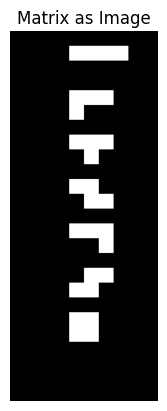

(array([[1., 1., 1., 1.]]), (24, 0))

In [16]:
# for example let's generate a library of pieces with the very basics and show it on the board
i = 1
board_example = np.zeros((25,10))
Pieces = []
Pieces.append( np.rot90(np.ones((4,1))) )
Pieces.append( np.array([ [1,1,1], [1,0,0] ]) )
Pieces.append( np.array([ [1,1,1], [0,1,0] ]) )
Pieces.append( np.array([ [1,1,0], [0,1,1] ]) )
Pieces.append( np.array([ [1,1,1], [0,0,1] ]) )
Pieces.append( np.array([ [0,1,1], [1,1,0] ]) )
Pieces.append( np.array([ [1,1], [1,1] ]) )
for piece in Pieces:
    m,n = np.shape(piece)
    board_example[i:i+m,4:4+n] = piece
    i = i+3
MatImshow(board_example)
piece2place = np.ones((1,4))
TetrisNext(board_example, piece2place, FollowingPieces = [], debugMode = False)

### Lets Play the Game

One piece is supplied by you.

Matrix:
|     1.00     1.00     1.00     1.00 |


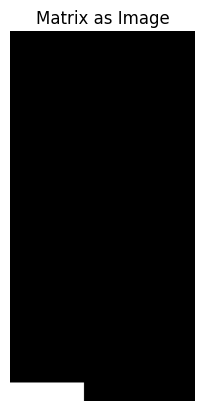

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.],
       [1., 1., 1., ..., 0., 0., 0.]])

In [19]:
# a single call for testing
H,W = 20, 10
M = np.zeros((H,W)) # empty board
nPreview = 3 # let's assume 3 piece preview
PP = [] # list of preview items
for i in range(nPreview+1): # fill in the list randomly with +1 that represents the piece2place
    PP.append( Pieces[np.random.randint(0, len(Pieces))] )
new_piece = PP.pop()
MatPrint(new_piece)
pf, i2p = TetrisNext(M, new_piece, [] )
M[i2p[0]:i2p[0]+pf.shape[0], i2p[1]:i2p[1]+pf.shape[1]] = pf
MatImshow(M)



9999 piece remaining.


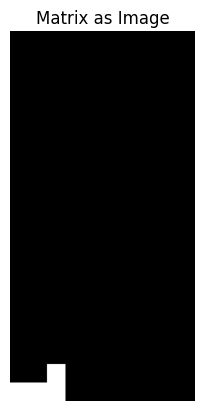

9998 piece remaining.


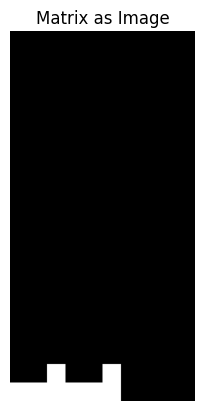

9997 piece remaining.


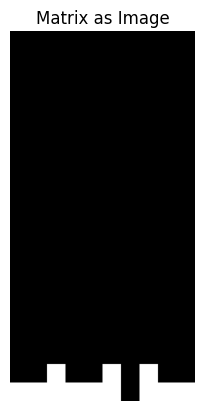

9996 piece remaining.


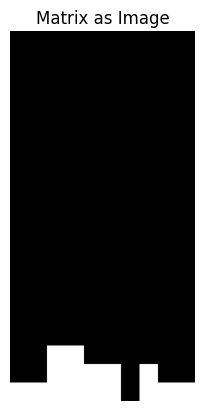

9995 piece remaining.


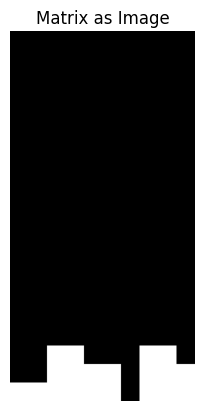

9994 piece remaining.


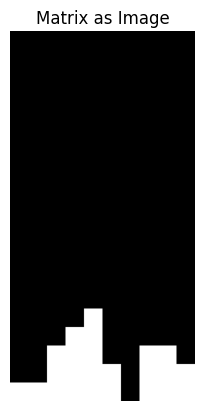

9993 piece remaining.


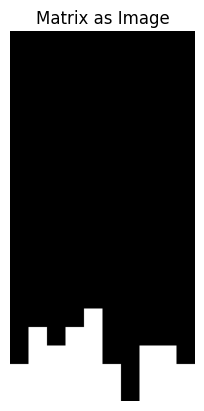

9992 piece remaining.


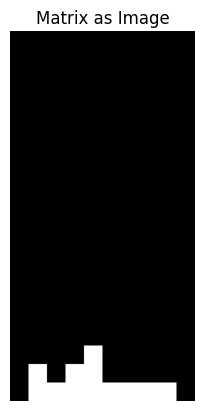

9991 piece remaining.


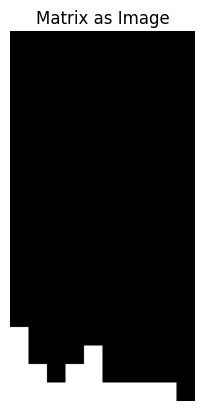

9990 piece remaining.


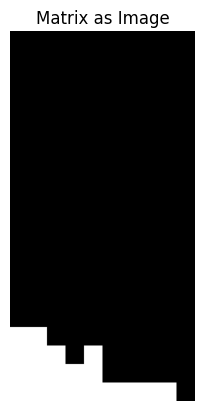

9989 piece remaining.


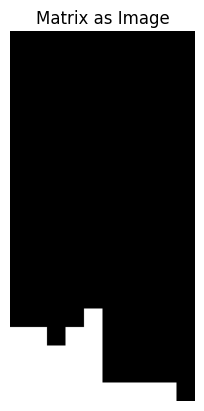

9988 piece remaining.


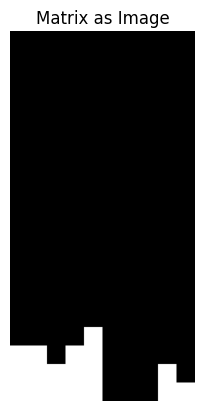

9987 piece remaining.


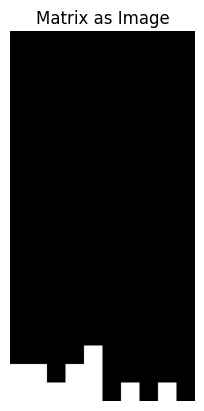

9986 piece remaining.


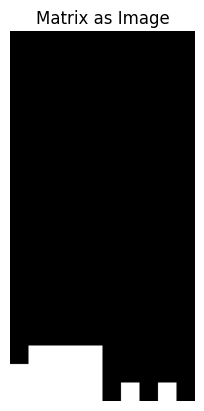

9985 piece remaining.


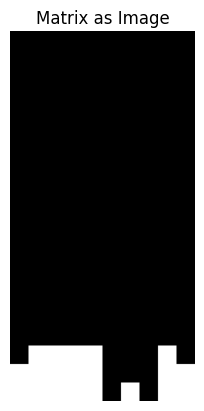

9984 piece remaining.


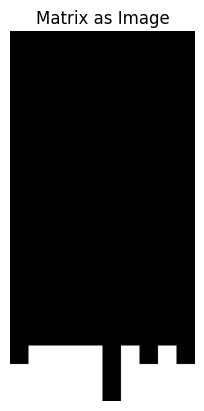

9983 piece remaining.


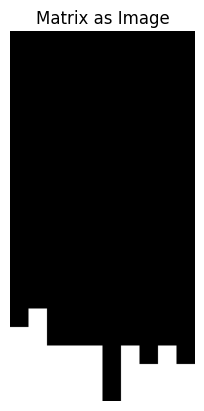

9982 piece remaining.


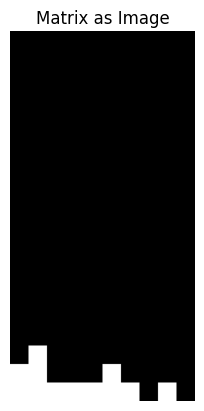

9981 piece remaining.


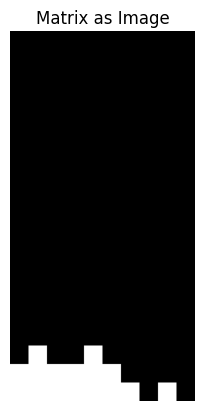

9980 piece remaining.


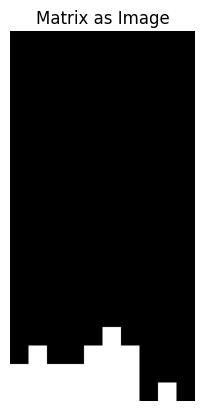

9979 piece remaining.


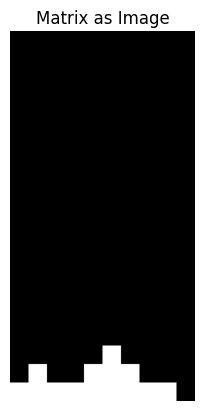

9978 piece remaining.


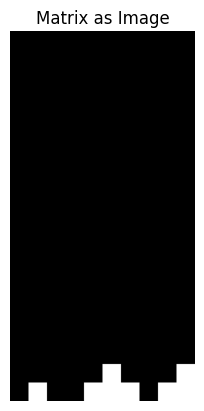

9977 piece remaining.


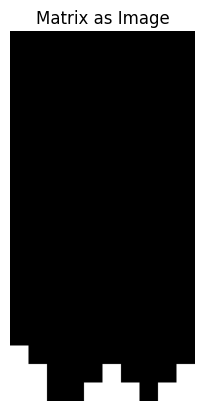

9976 piece remaining.


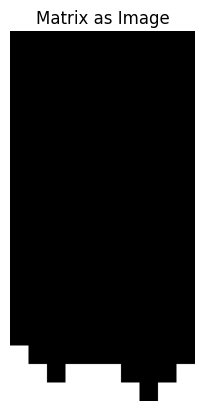

9975 piece remaining.


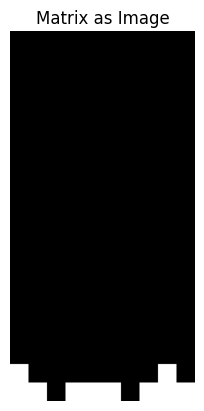

9974 piece remaining.


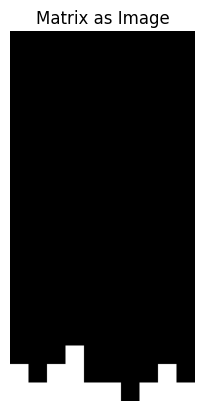

9973 piece remaining.


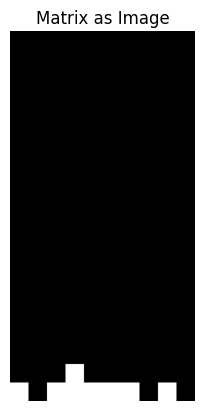

9972 piece remaining.


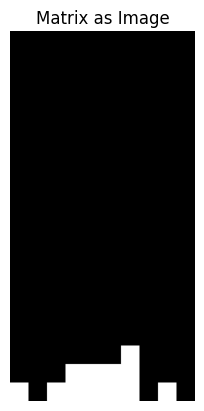

9971 piece remaining.


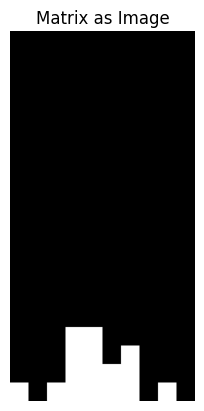

9970 piece remaining.


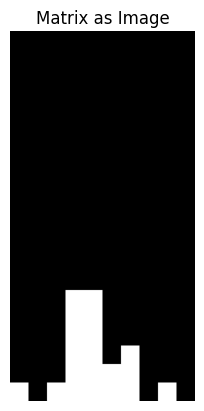

9969 piece remaining.


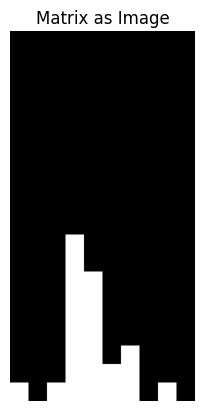

9968 piece remaining.


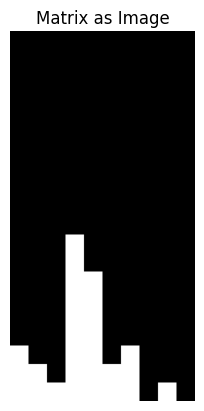

9967 piece remaining.


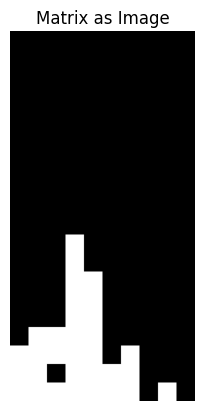

9966 piece remaining.


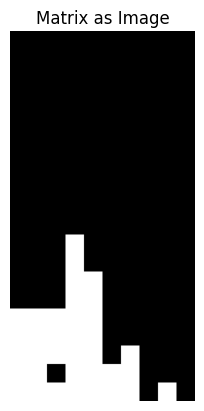

9965 piece remaining.


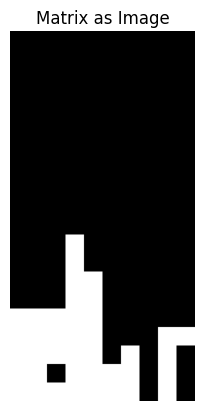

9964 piece remaining.


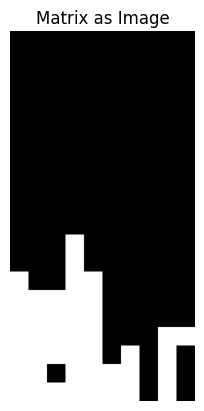

9963 piece remaining.


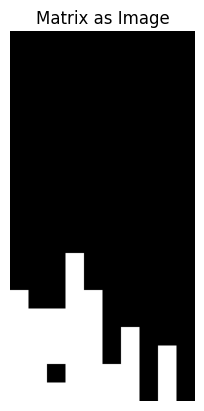

9962 piece remaining.


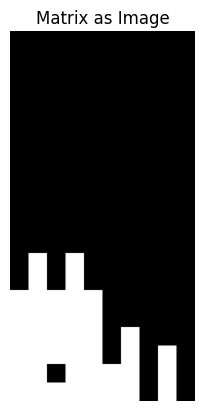

9961 piece remaining.


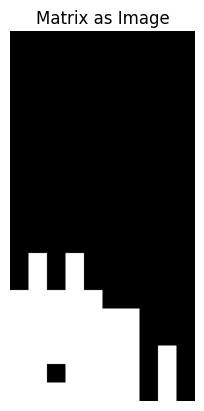

9960 piece remaining.


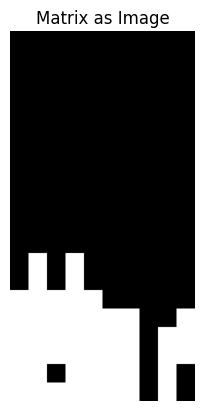

9959 piece remaining.


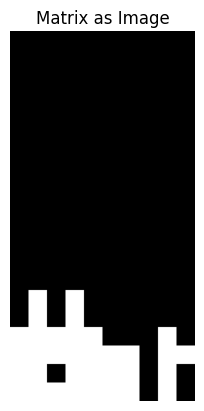

9958 piece remaining.


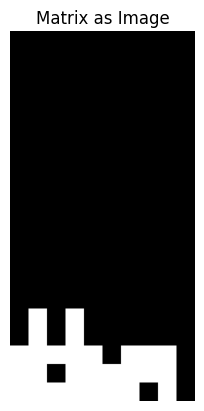

9957 piece remaining.


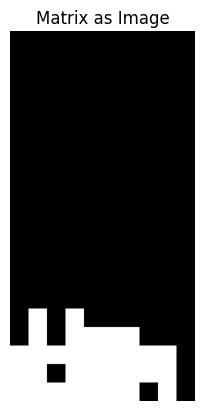

9956 piece remaining.


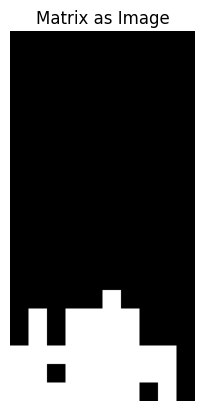

9955 piece remaining.


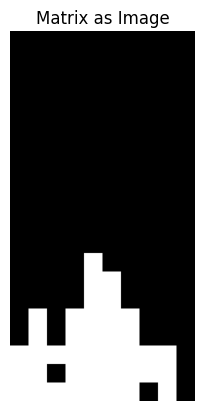

9954 piece remaining.


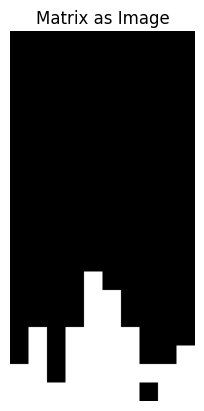

9953 piece remaining.


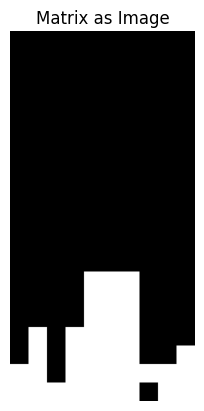

9952 piece remaining.


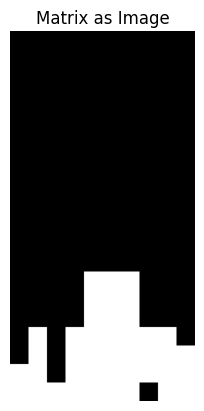

9951 piece remaining.


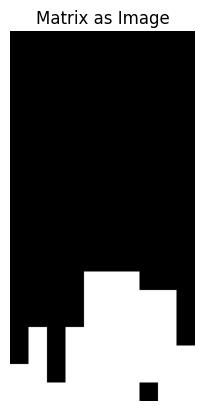

9950 piece remaining.


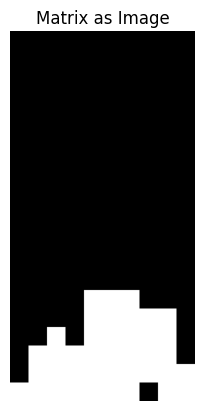

9949 piece remaining.


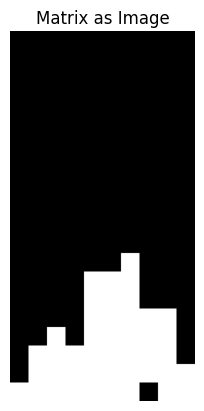

9948 piece remaining.


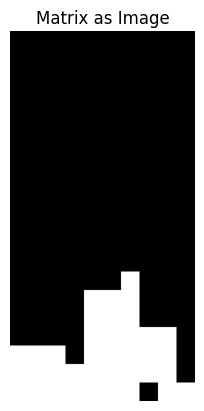

9947 piece remaining.


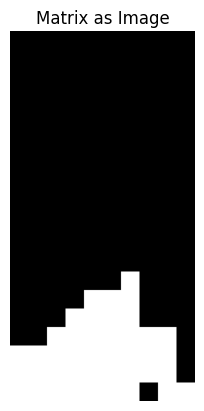

9946 piece remaining.


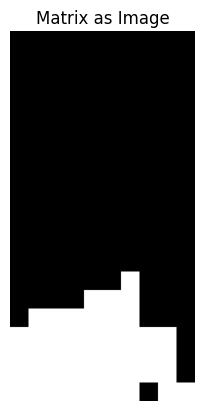

9945 piece remaining.


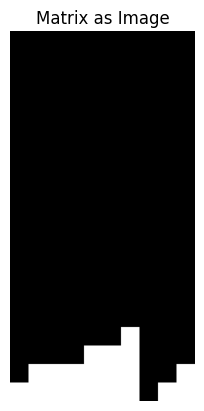

9944 piece remaining.


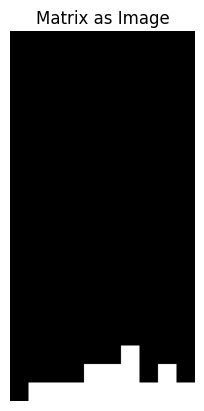

9943 piece remaining.


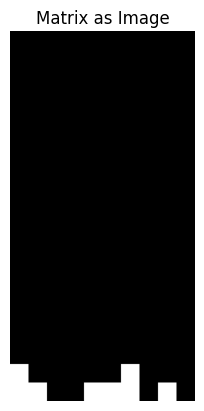

9942 piece remaining.


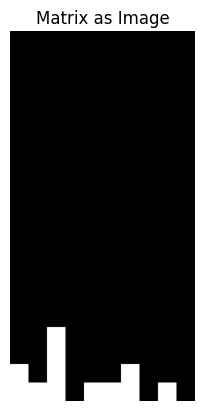

9941 piece remaining.


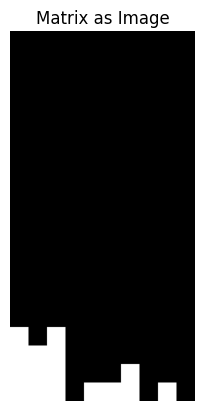

9940 piece remaining.


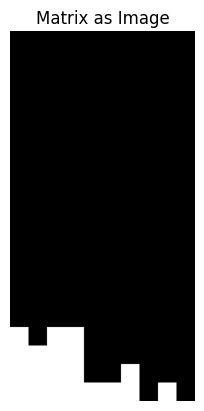

9939 piece remaining.


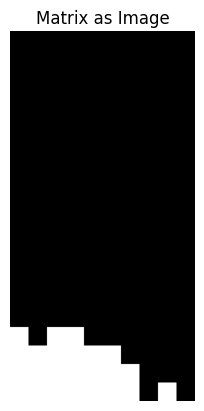

9938 piece remaining.


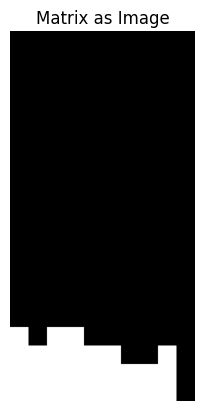

9937 piece remaining.


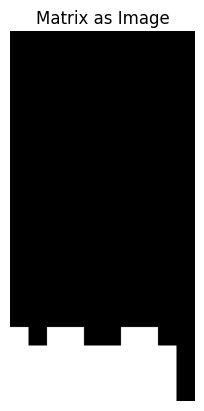

9936 piece remaining.


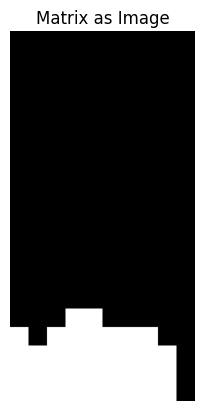

9935 piece remaining.


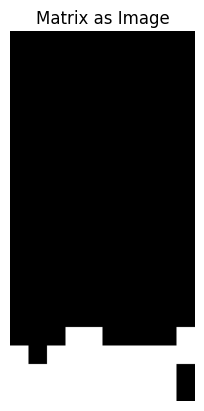

9934 piece remaining.


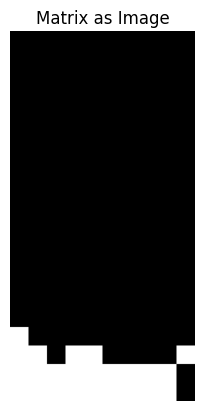

9933 piece remaining.


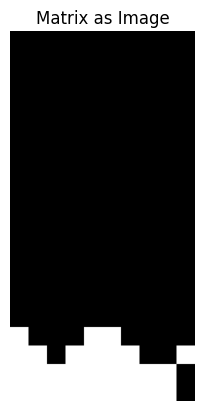

9932 piece remaining.


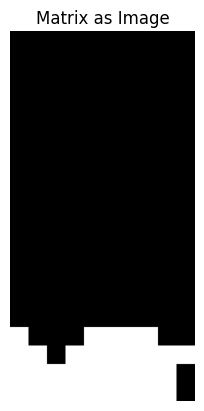

9931 piece remaining.


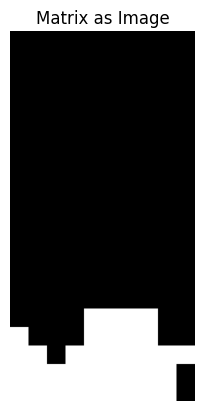

9930 piece remaining.


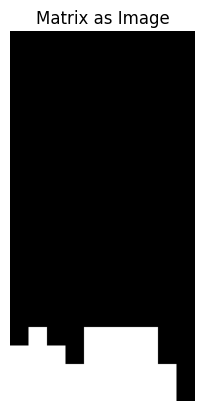

9929 piece remaining.


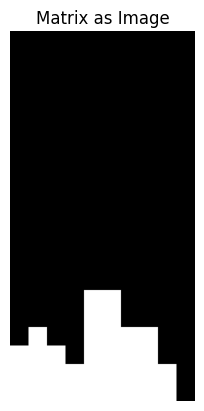

9928 piece remaining.


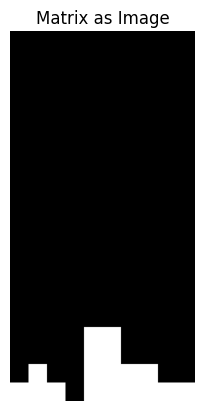

9927 piece remaining.


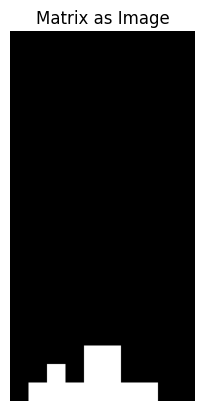

9926 piece remaining.


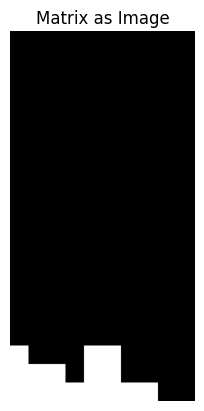

9925 piece remaining.


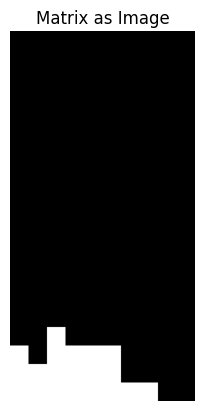

9924 piece remaining.


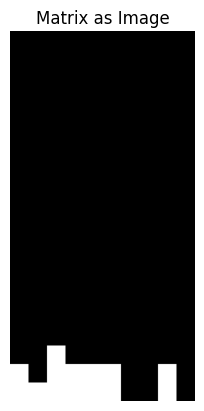

9923 piece remaining.


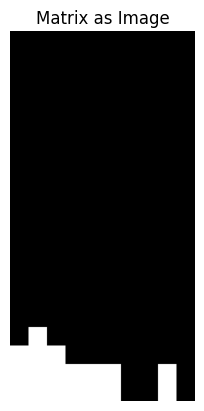

9922 piece remaining.


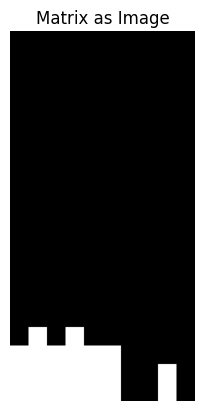

9921 piece remaining.


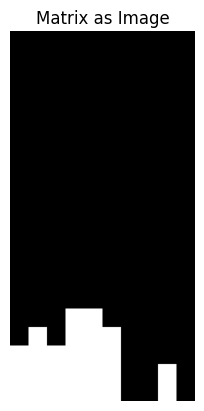

9920 piece remaining.


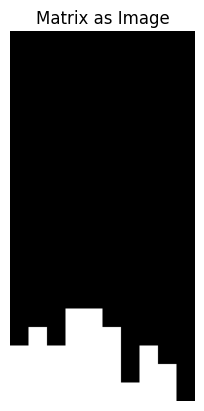

9919 piece remaining.


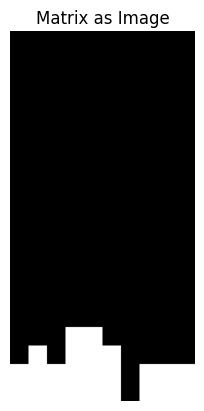

9918 piece remaining.


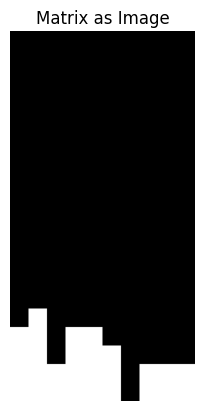

9917 piece remaining.


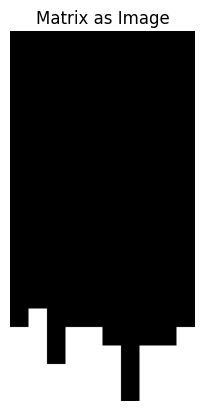

9916 piece remaining.


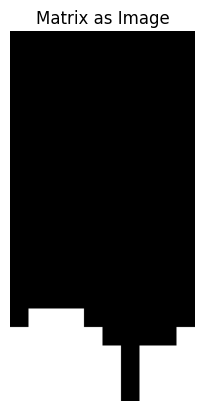

9915 piece remaining.


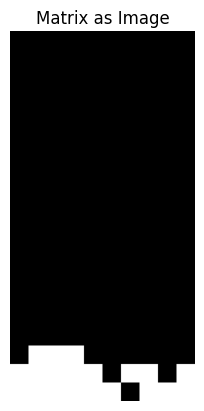

9914 piece remaining.


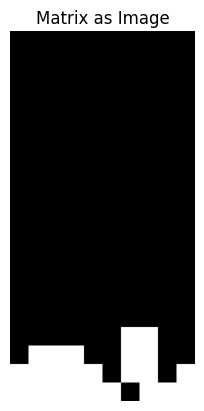

9913 piece remaining.


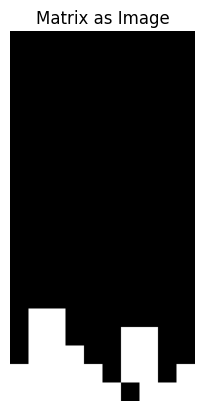

9912 piece remaining.


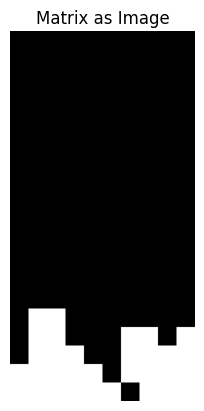

9911 piece remaining.


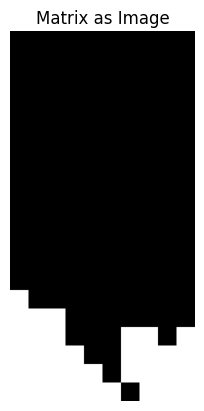

9910 piece remaining.


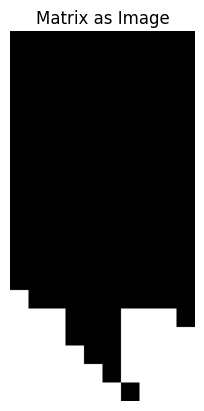

9909 piece remaining.


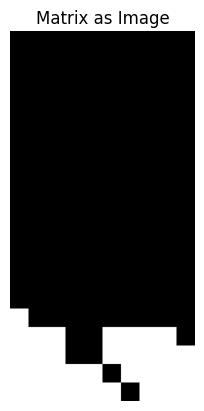

9908 piece remaining.


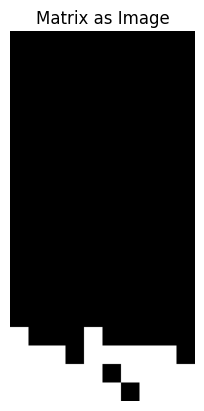

9907 piece remaining.


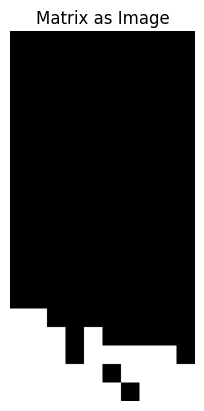

9906 piece remaining.


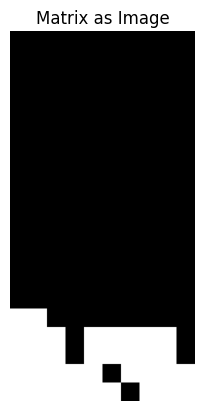

9905 piece remaining.


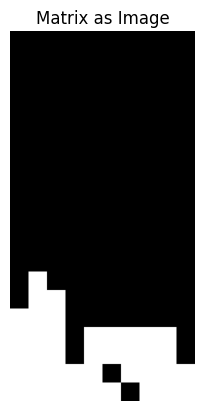

9904 piece remaining.


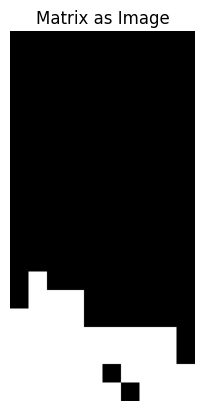

9903 piece remaining.


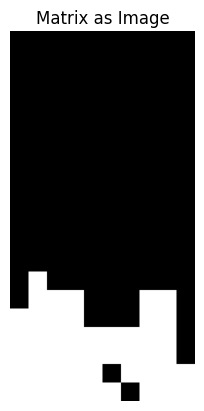

9902 piece remaining.


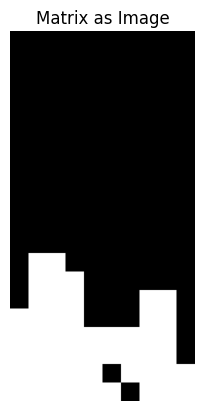

9901 piece remaining.


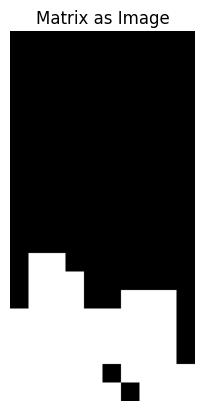

9900 piece remaining.


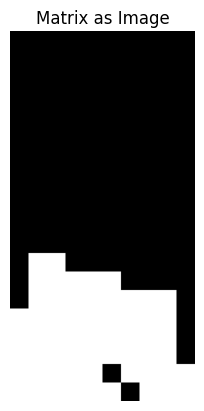

9899 piece remaining.


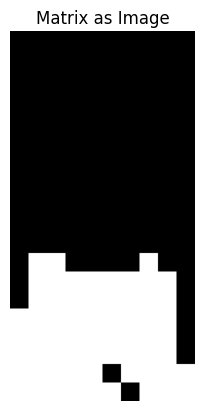

9898 piece remaining.


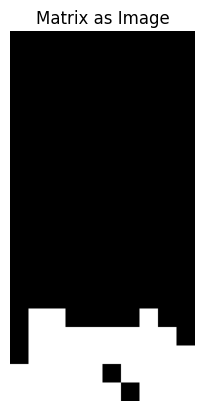

9897 piece remaining.


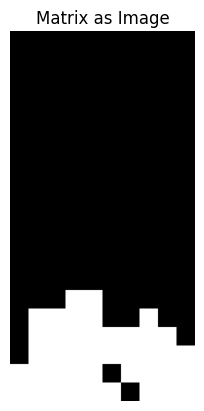

9896 piece remaining.


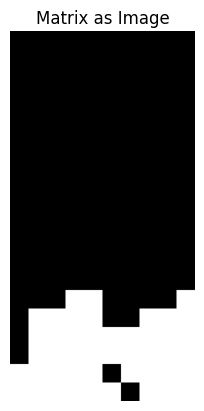

9895 piece remaining.


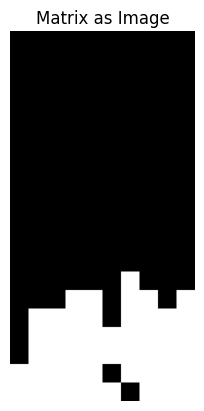

9894 piece remaining.


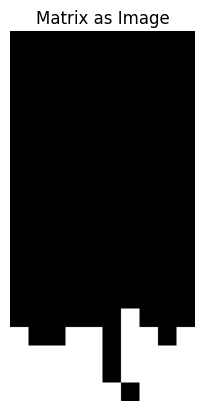

9893 piece remaining.


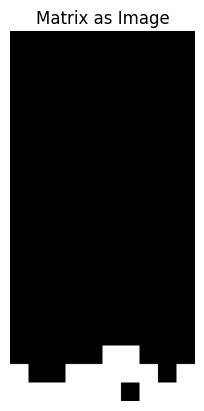

9892 piece remaining.


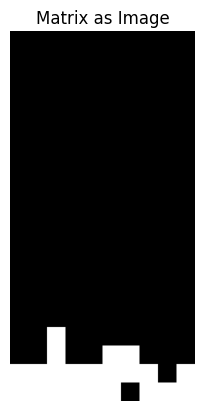

9891 piece remaining.


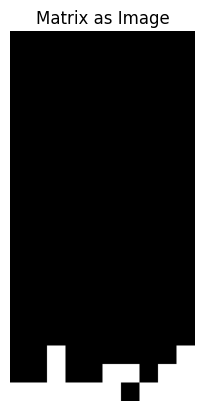

9890 piece remaining.


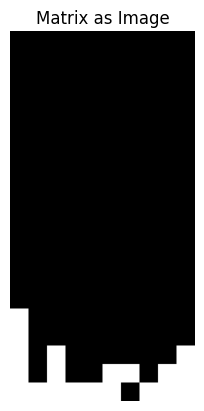

9889 piece remaining.


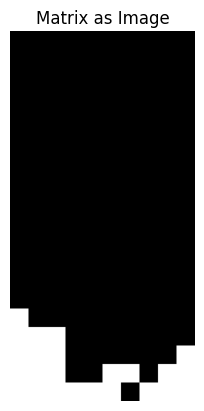

9888 piece remaining.


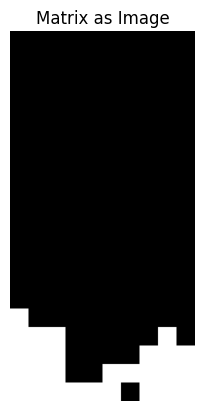

9887 piece remaining.


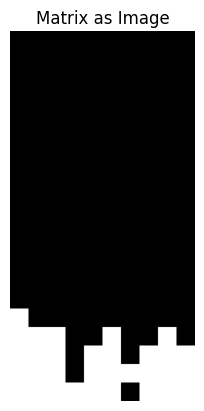

9886 piece remaining.


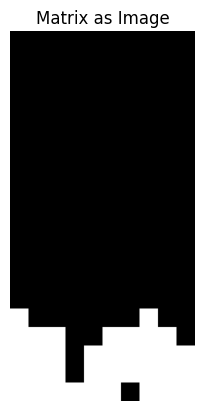

9885 piece remaining.


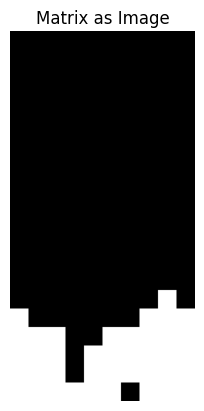

9884 piece remaining.


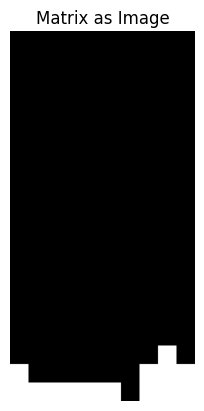

9883 piece remaining.


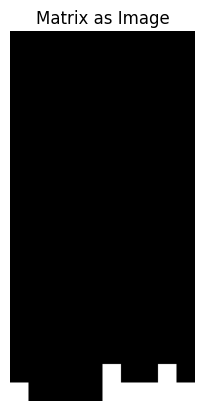

9882 piece remaining.


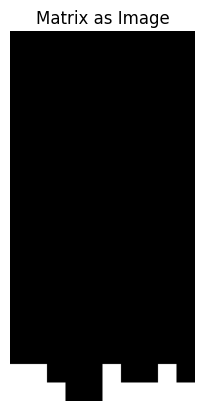

9881 piece remaining.


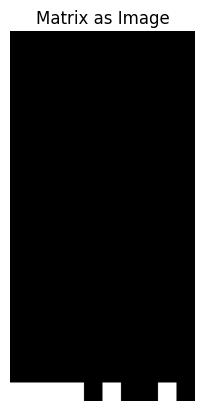

9880 piece remaining.


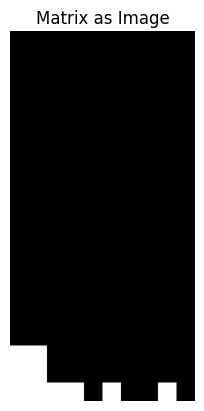

9879 piece remaining.


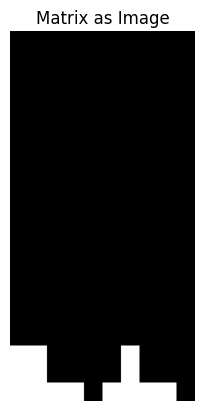

9878 piece remaining.


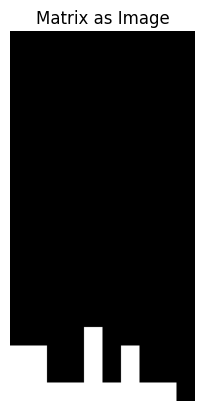

9877 piece remaining.


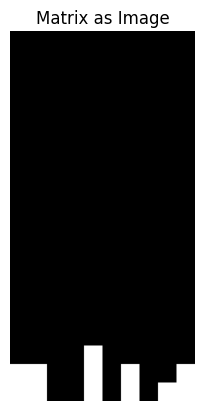

9876 piece remaining.


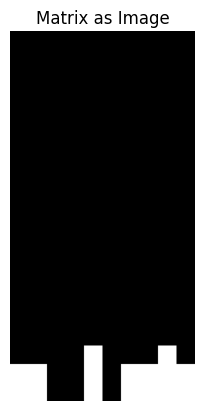

9875 piece remaining.


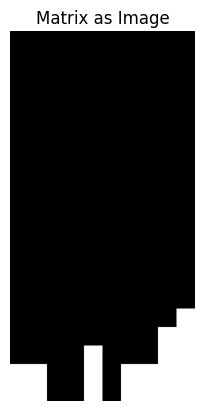

9874 piece remaining.


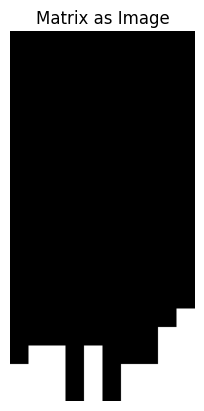

9873 piece remaining.


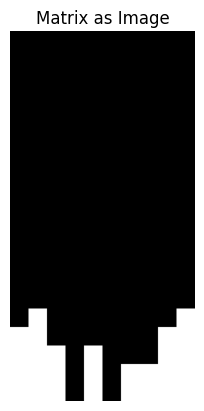

9872 piece remaining.


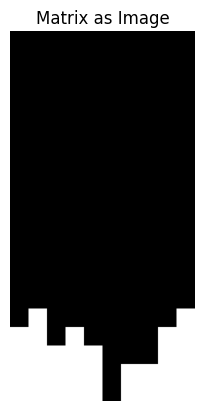

9871 piece remaining.


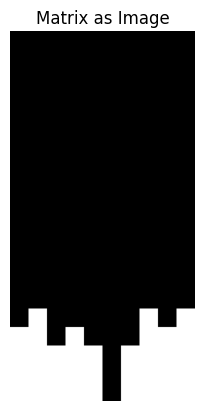

9870 piece remaining.


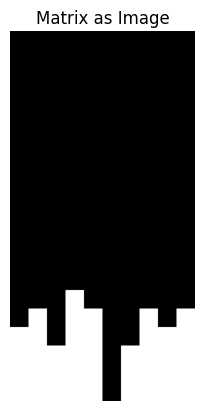

9869 piece remaining.


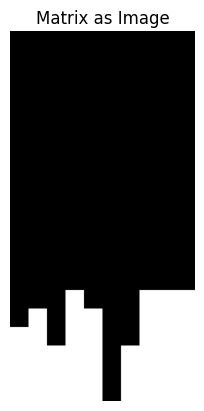

9868 piece remaining.


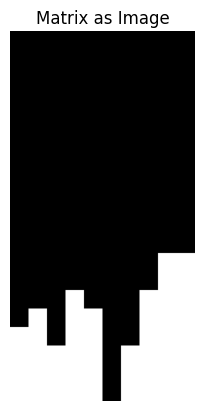

9867 piece remaining.


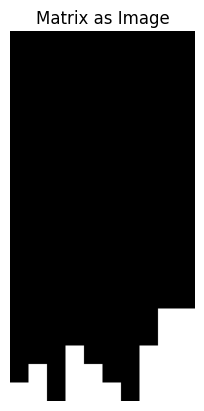

9866 piece remaining.


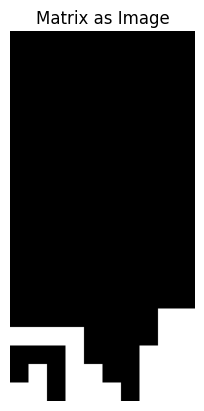

9865 piece remaining.


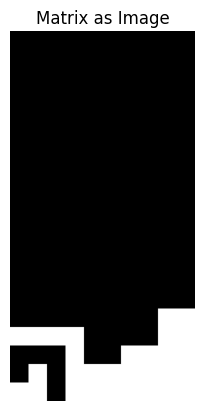

9864 piece remaining.


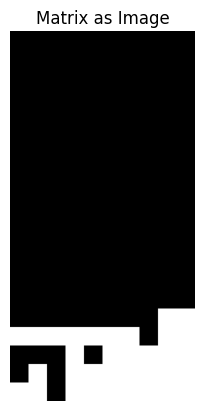

9863 piece remaining.


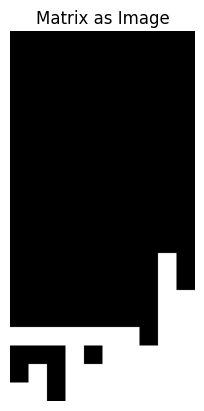

9862 piece remaining.


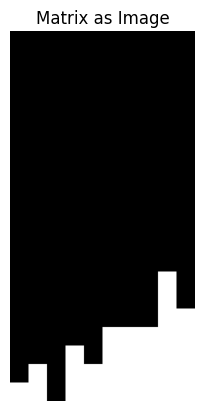

9861 piece remaining.


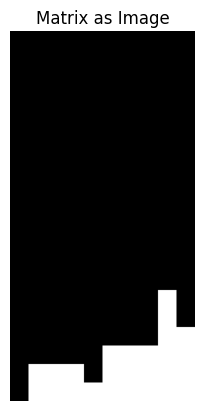

9860 piece remaining.


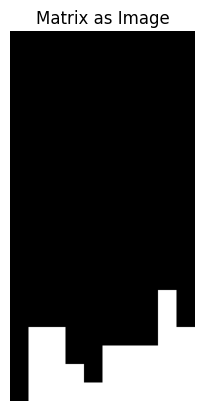

9859 piece remaining.


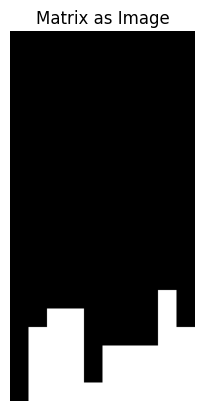

9858 piece remaining.


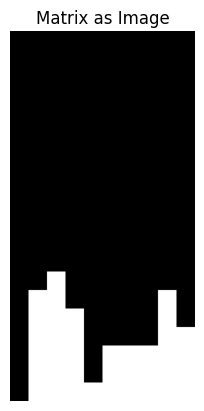

9857 piece remaining.


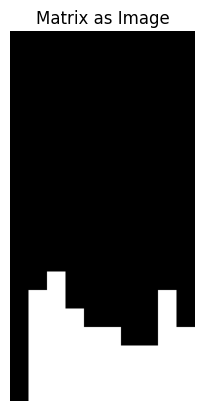

9856 piece remaining.


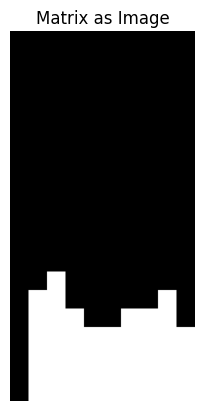

9855 piece remaining.


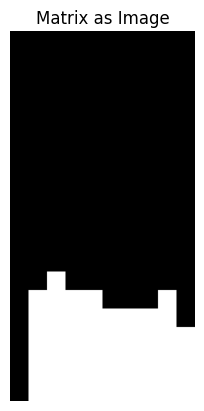

9854 piece remaining.


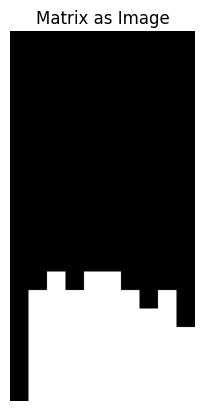

9853 piece remaining.


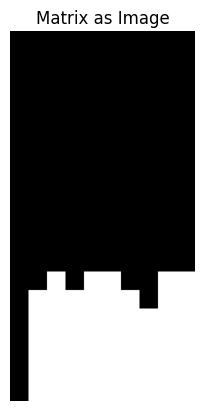

9852 piece remaining.


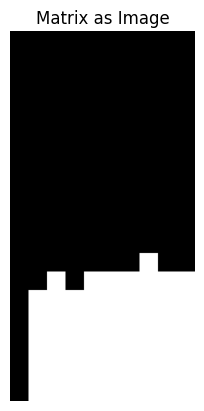

9851 piece remaining.


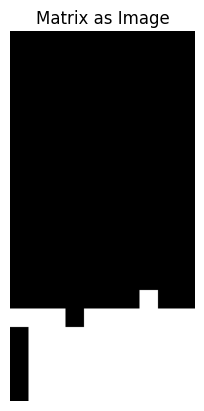

9850 piece remaining.


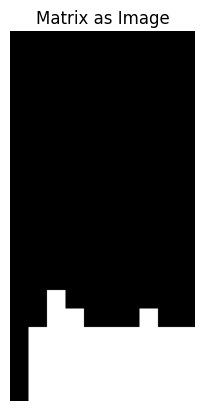

9849 piece remaining.


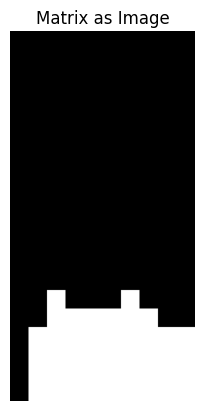

9848 piece remaining.


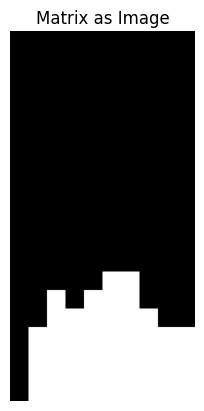

9847 piece remaining.


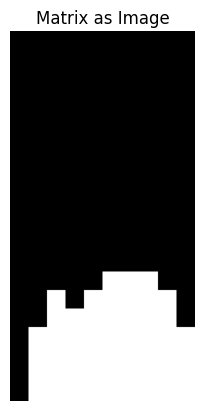

9846 piece remaining.


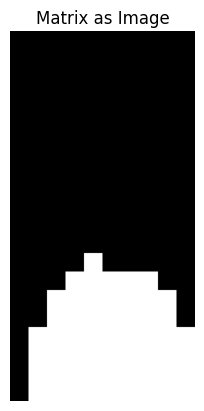

9845 piece remaining.


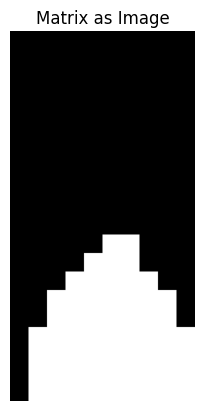

9844 piece remaining.


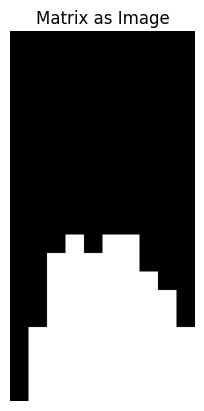

9843 piece remaining.


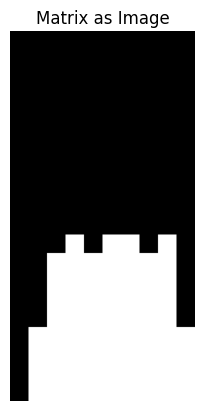

9842 piece remaining.


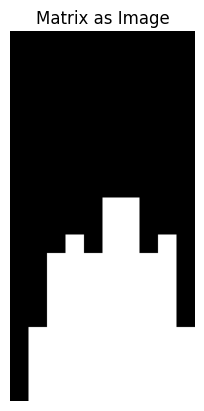

9841 piece remaining.


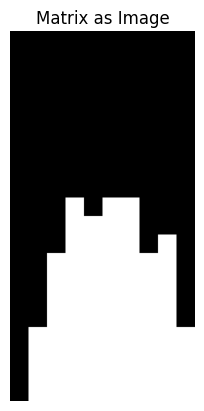

9840 piece remaining.


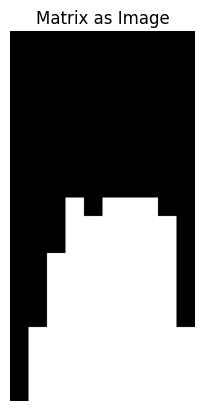

9839 piece remaining.


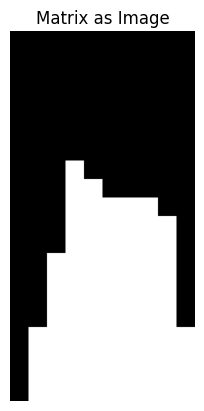

9838 piece remaining.


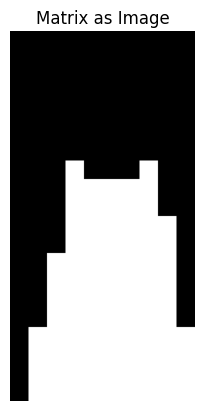

9837 piece remaining.


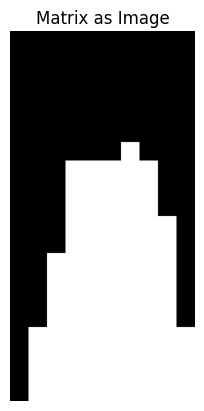

9836 piece remaining.


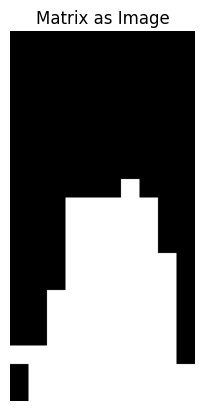

9835 piece remaining.


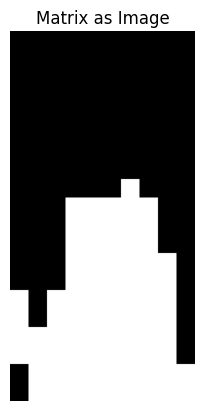

9834 piece remaining.


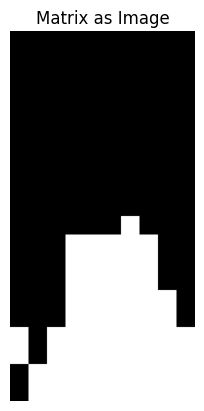

9833 piece remaining.


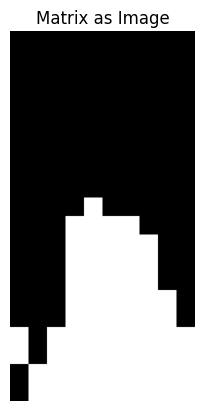

9832 piece remaining.


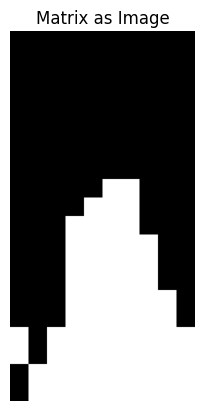

9831 piece remaining.


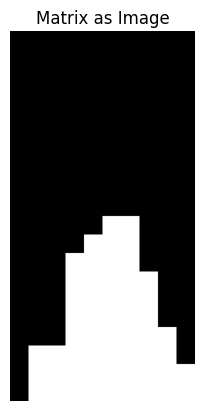

9830 piece remaining.


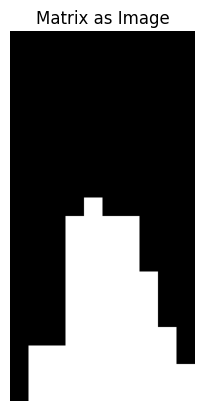

9829 piece remaining.


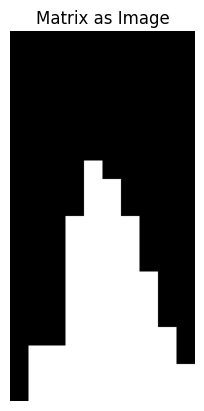

9828 piece remaining.


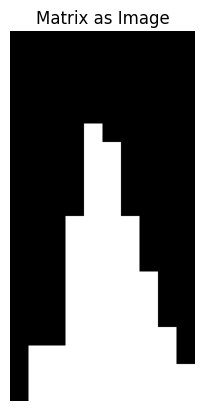

9827 piece remaining.


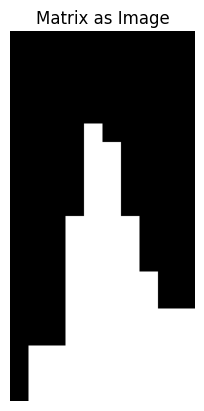

9826 piece remaining.


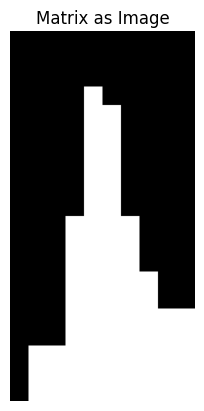

9825 piece remaining.


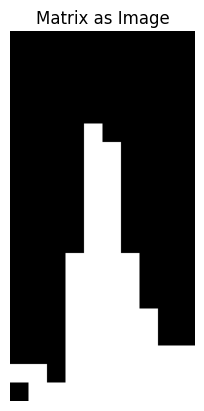

9824 piece remaining.


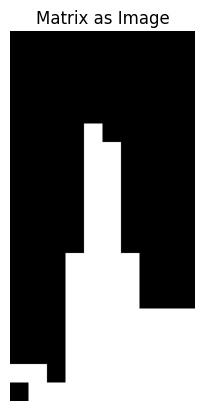

9823 piece remaining.


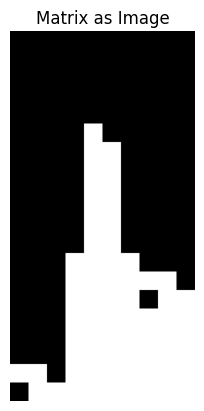

9822 piece remaining.


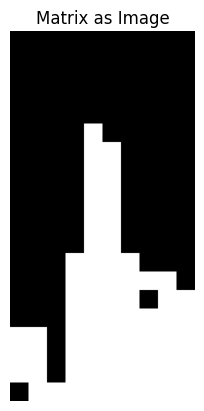

9821 piece remaining.


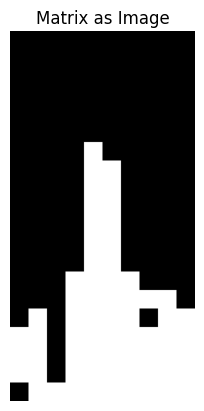

9820 piece remaining.


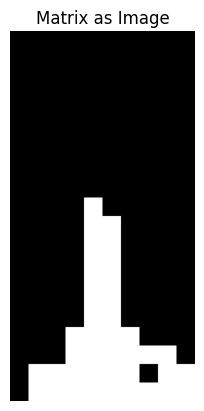

9819 piece remaining.


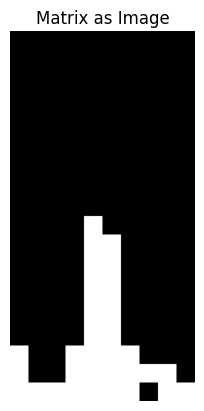

9818 piece remaining.


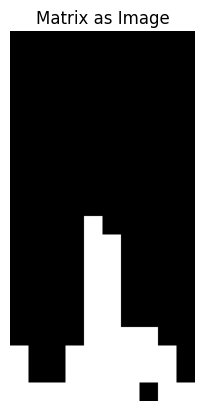

9817 piece remaining.


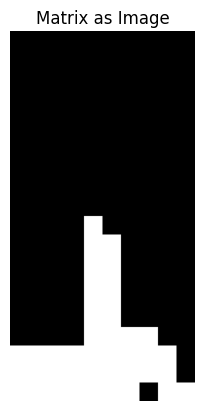

9816 piece remaining.


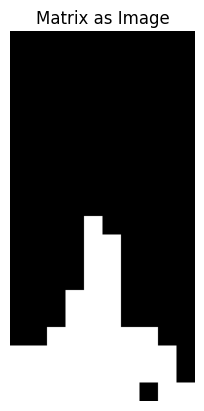

9815 piece remaining.


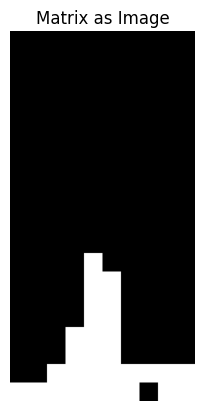

9814 piece remaining.


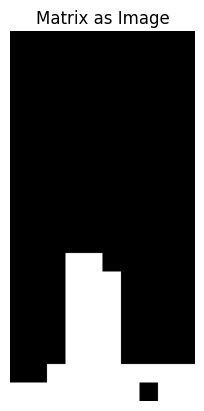

9813 piece remaining.


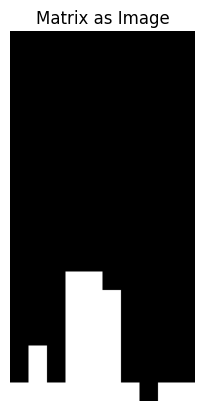

9812 piece remaining.


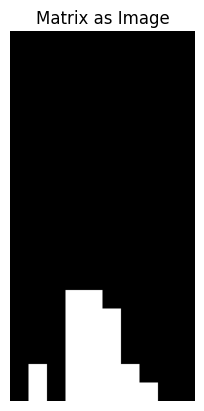

9811 piece remaining.


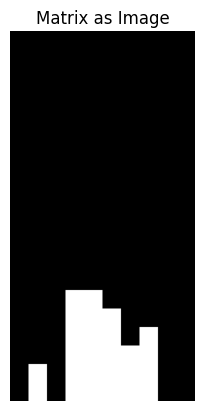

9810 piece remaining.


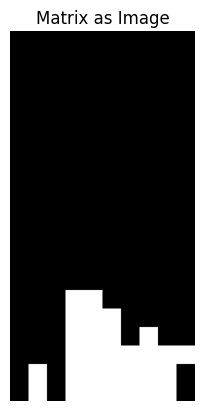

9809 piece remaining.


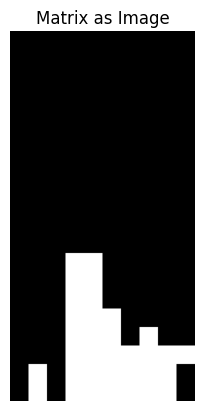

9808 piece remaining.


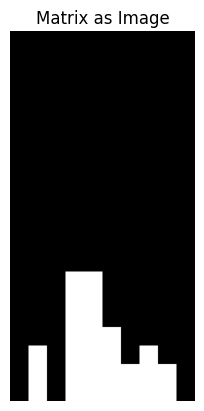

9807 piece remaining.


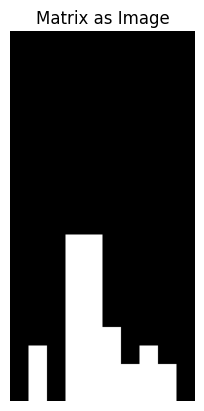

9806 piece remaining.


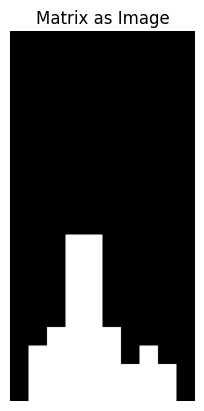

9805 piece remaining.


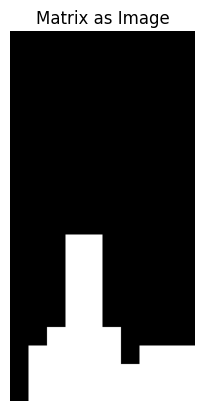

9804 piece remaining.


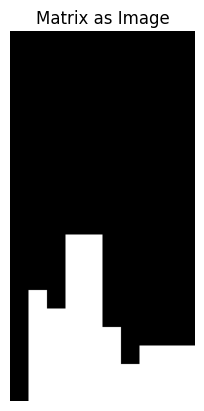

9803 piece remaining.


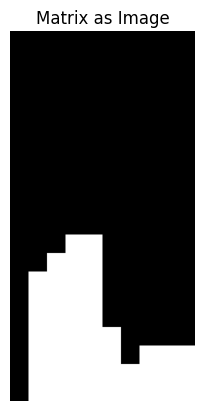

9802 piece remaining.


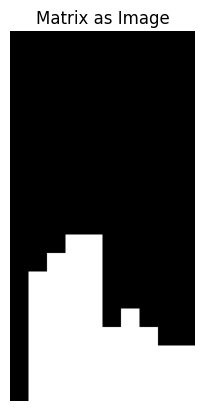

9801 piece remaining.


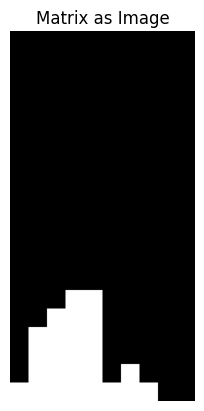

9800 piece remaining.


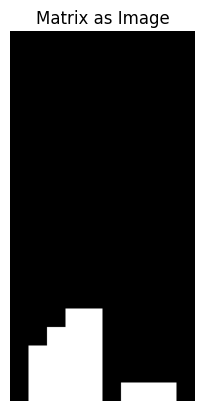

9799 piece remaining.


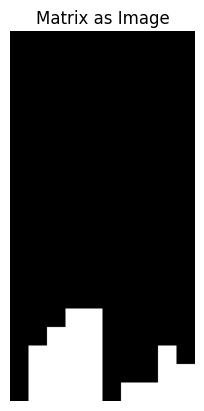

9798 piece remaining.


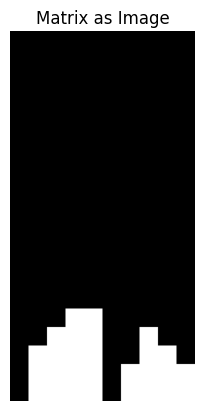

9797 piece remaining.


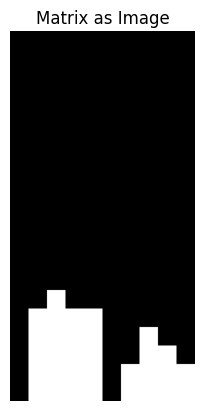

9796 piece remaining.


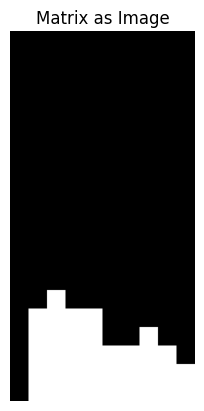

9795 piece remaining.


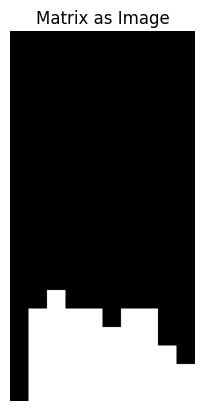

9794 piece remaining.


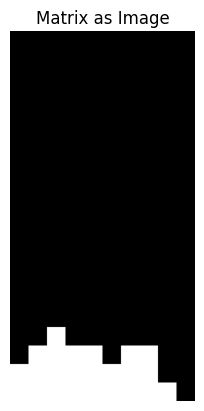

9793 piece remaining.


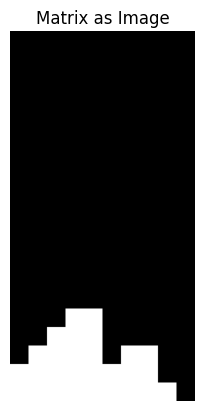

9792 piece remaining.


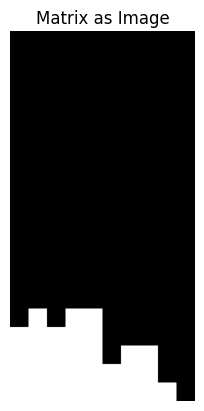

9791 piece remaining.


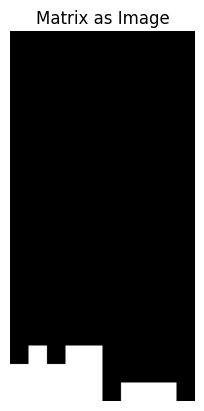

9790 piece remaining.


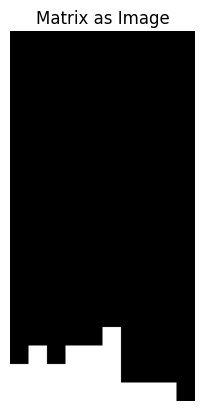

9789 piece remaining.


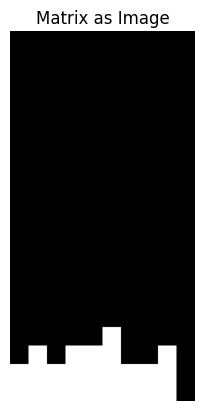

9788 piece remaining.


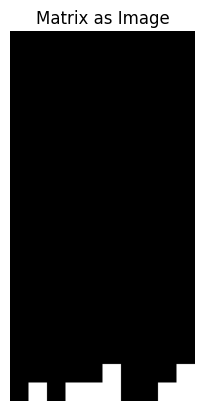

9787 piece remaining.


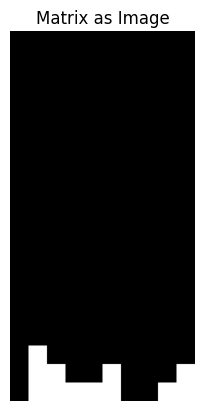

9786 piece remaining.


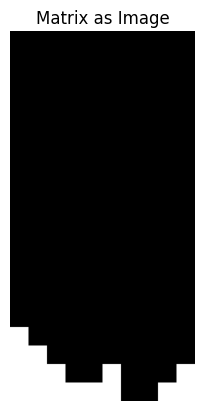

9785 piece remaining.


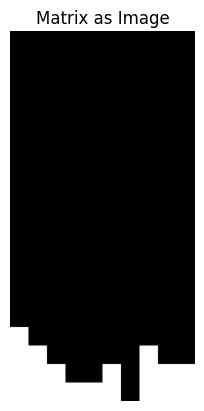

9784 piece remaining.


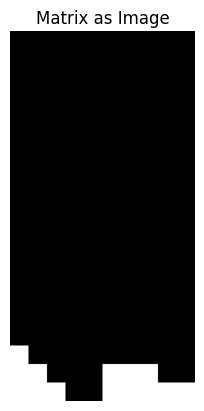

9783 piece remaining.


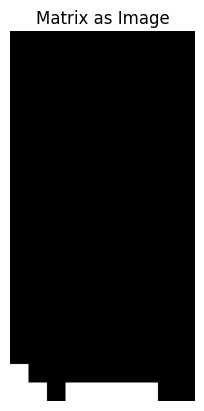

9782 piece remaining.


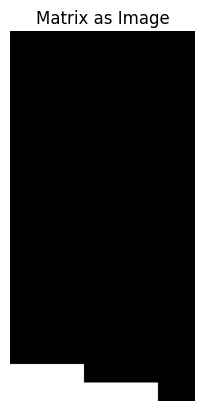

9781 piece remaining.


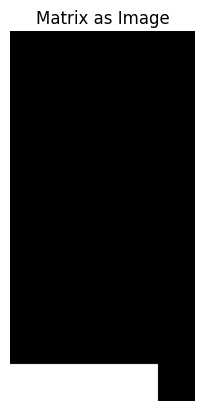

9780 piece remaining.


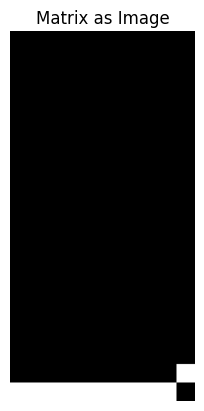

9779 piece remaining.


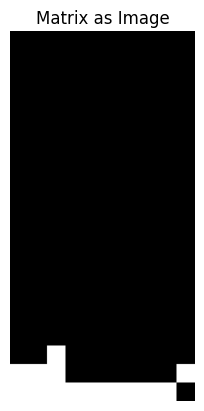

9778 piece remaining.


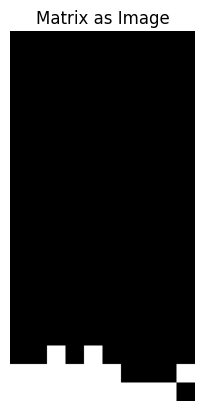

9777 piece remaining.


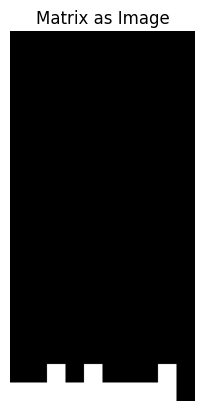

9776 piece remaining.


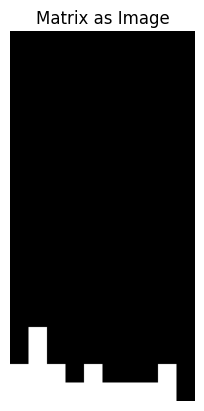

9775 piece remaining.


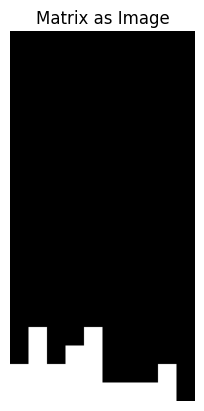

9774 piece remaining.


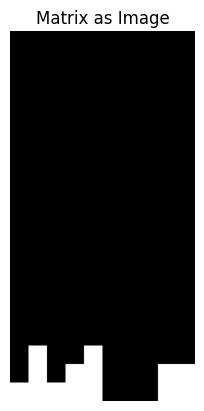

9773 piece remaining.


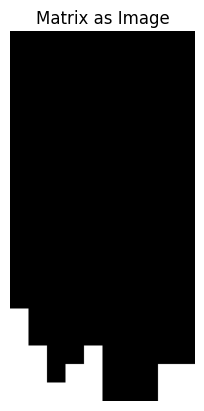

9772 piece remaining.


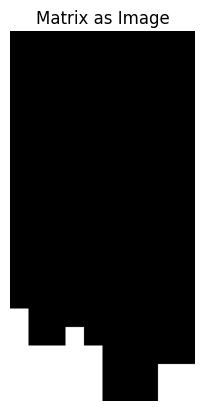

9771 piece remaining.


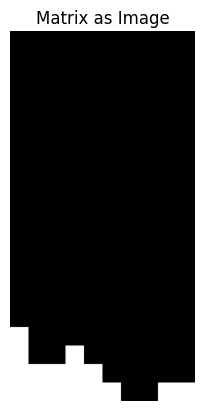

9770 piece remaining.


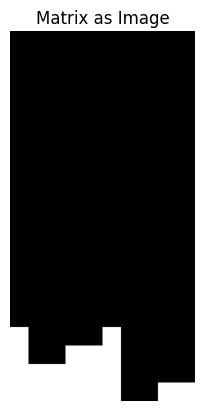

9769 piece remaining.


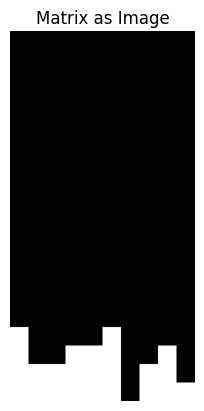

9768 piece remaining.


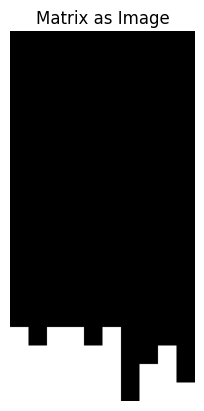

9767 piece remaining.


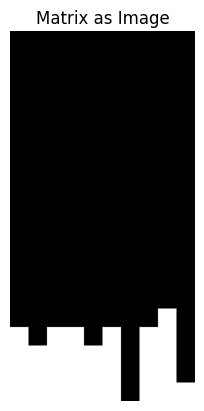

9766 piece remaining.


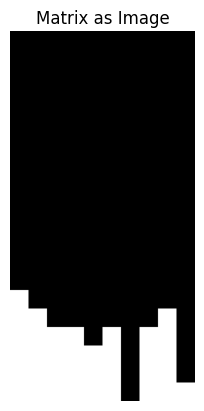

9765 piece remaining.


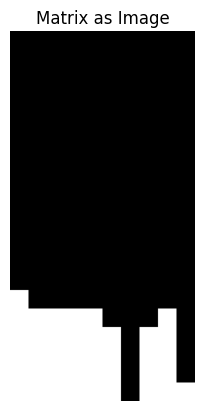

9764 piece remaining.


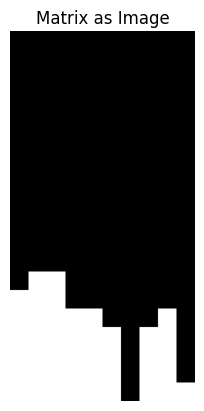

9763 piece remaining.


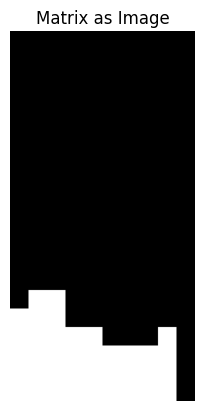

9762 piece remaining.


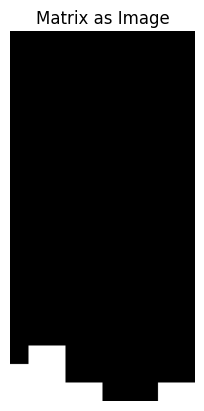

9761 piece remaining.


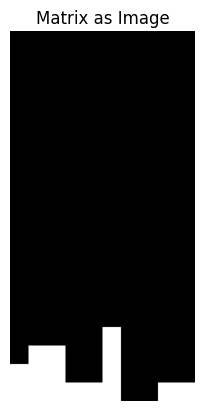

9760 piece remaining.


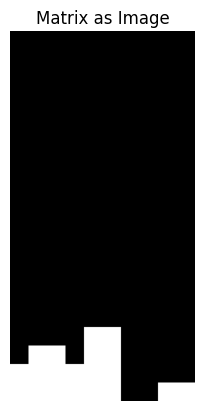

9759 piece remaining.


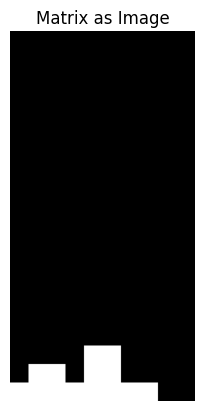

9758 piece remaining.


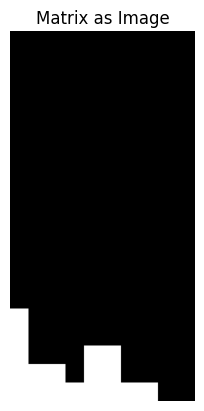

9757 piece remaining.


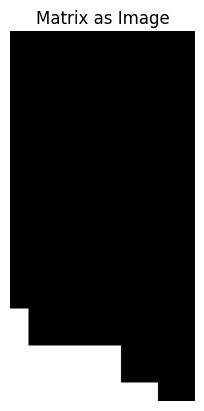

9756 piece remaining.


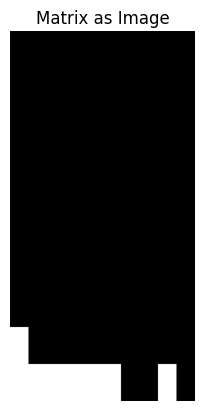

9755 piece remaining.


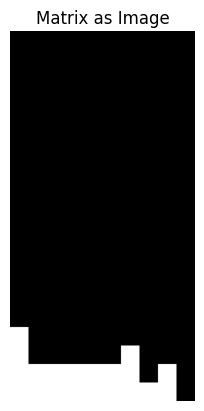

9754 piece remaining.


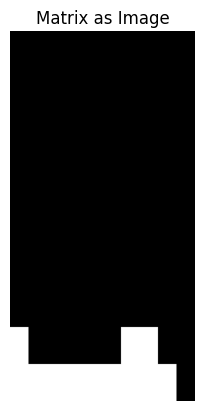

9753 piece remaining.


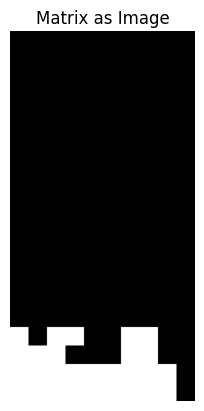

9752 piece remaining.


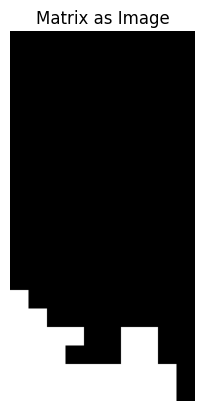

9751 piece remaining.


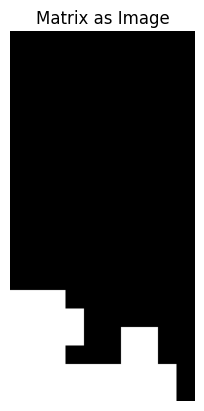

9750 piece remaining.


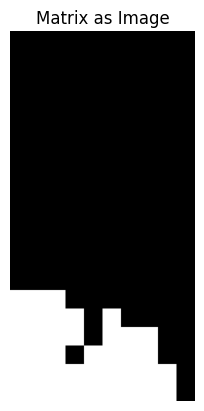

9749 piece remaining.


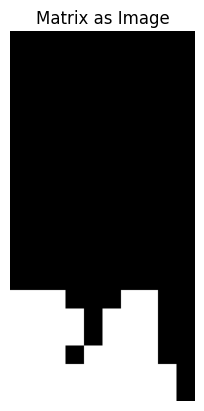

9748 piece remaining.


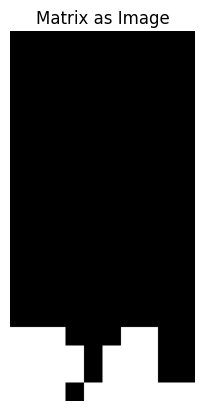

9747 piece remaining.


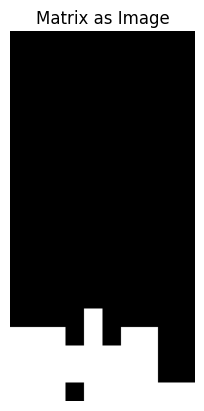

9746 piece remaining.


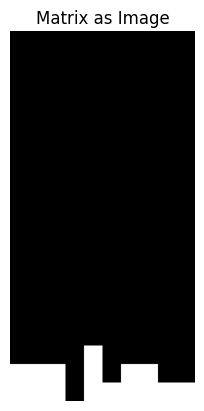

9745 piece remaining.


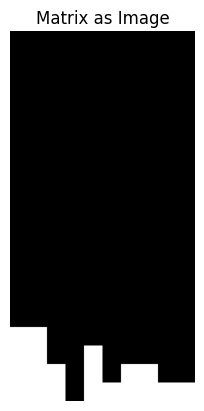

9744 piece remaining.


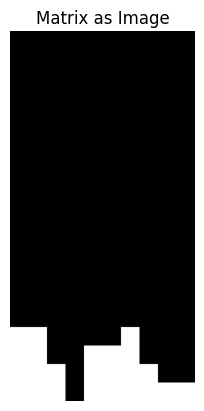

9743 piece remaining.


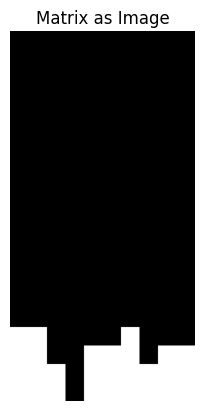

9742 piece remaining.


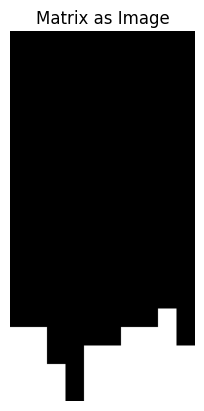

9741 piece remaining.


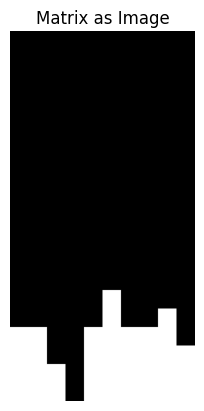

9740 piece remaining.


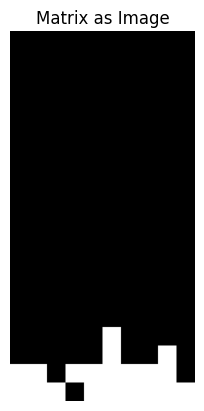

9739 piece remaining.


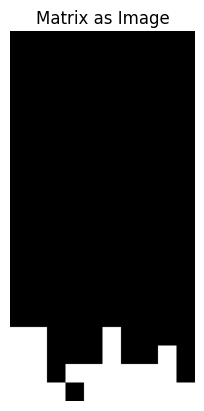

9738 piece remaining.


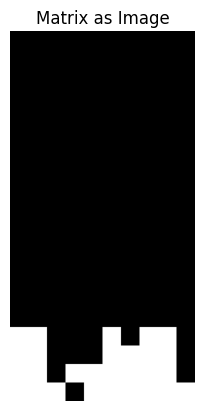

9737 piece remaining.


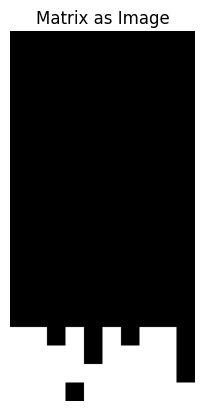

9736 piece remaining.


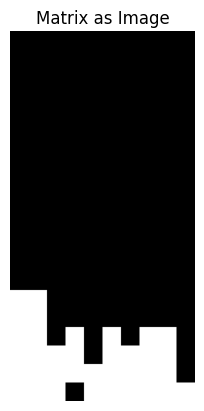

9735 piece remaining.


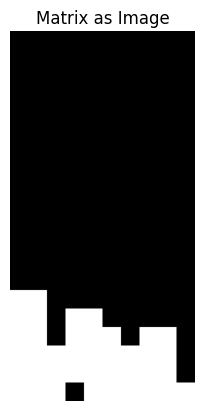

9734 piece remaining.


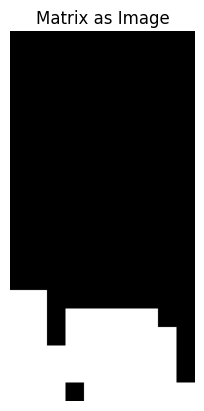

9733 piece remaining.


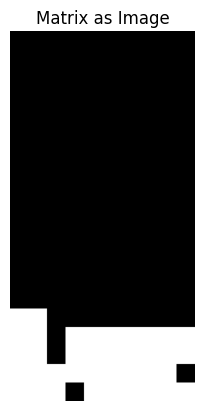

9732 piece remaining.


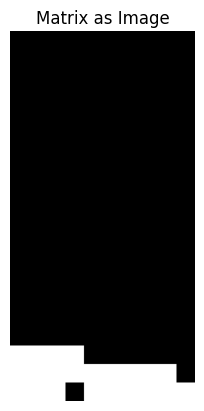

9731 piece remaining.


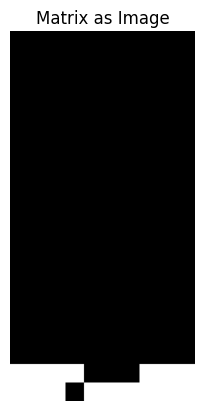

9730 piece remaining.


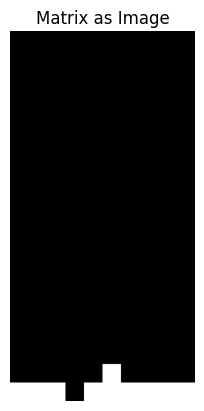

9729 piece remaining.


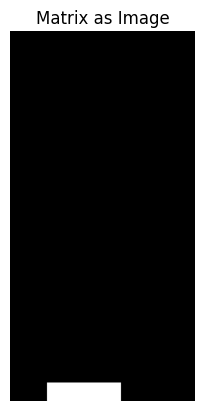

9728 piece remaining.


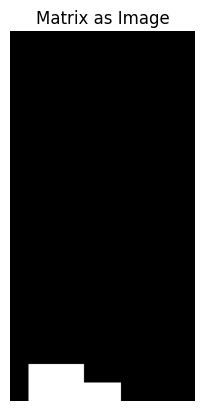

9727 piece remaining.


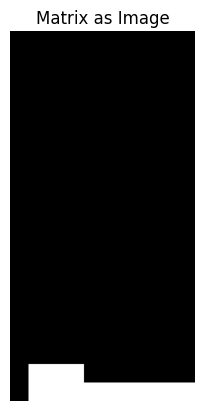

9726 piece remaining.


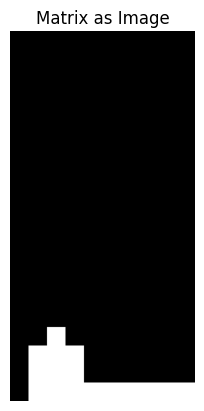

9725 piece remaining.


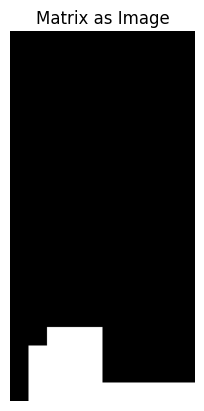

9724 piece remaining.


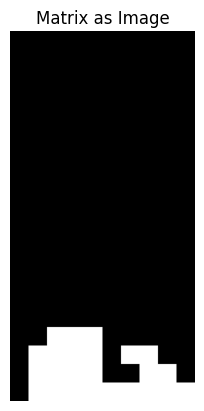

9723 piece remaining.


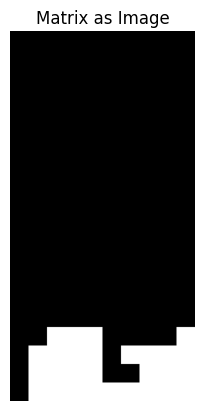

9722 piece remaining.


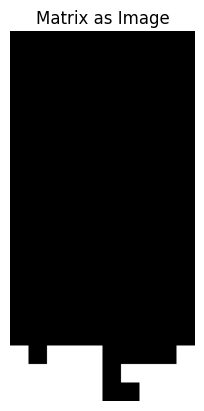

9721 piece remaining.


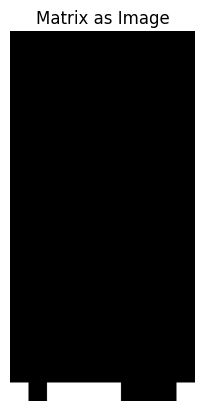

9720 piece remaining.


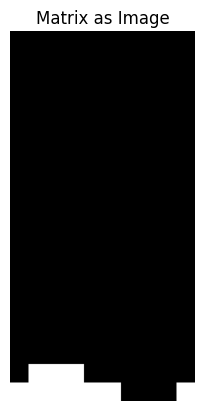

9719 piece remaining.


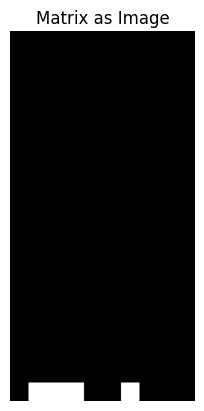

9718 piece remaining.


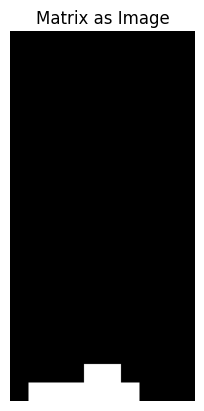

9717 piece remaining.


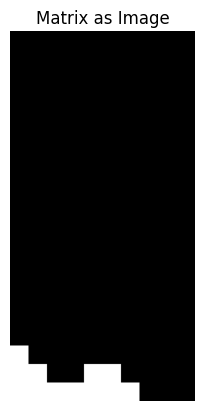

9716 piece remaining.


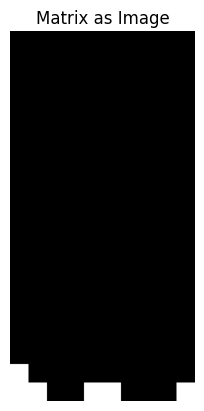

9715 piece remaining.


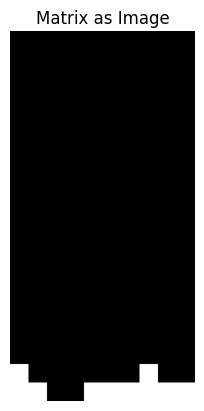

9714 piece remaining.


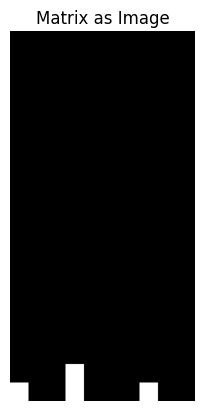

9713 piece remaining.


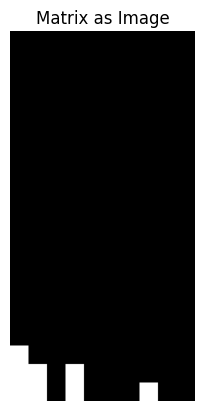

9712 piece remaining.


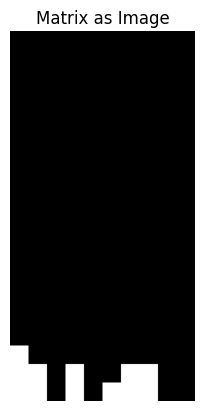

9711 piece remaining.


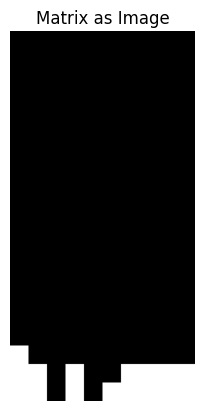

9710 piece remaining.


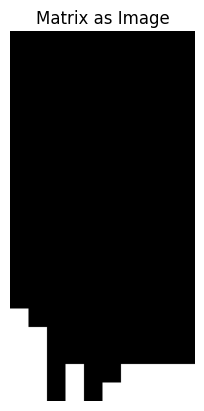

9709 piece remaining.


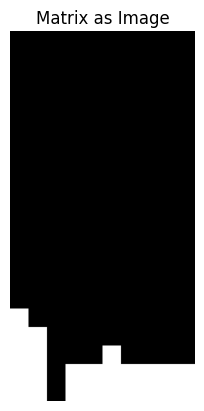

9708 piece remaining.


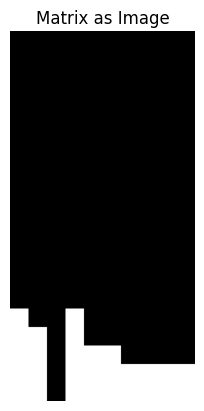

9707 piece remaining.


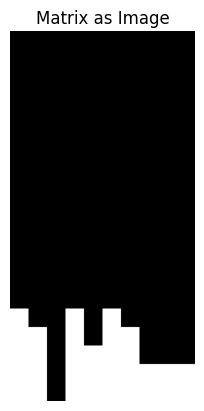

9706 piece remaining.


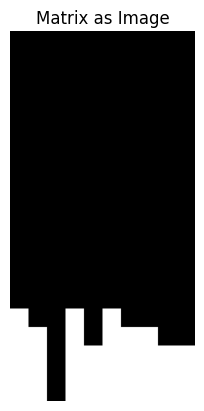

9705 piece remaining.


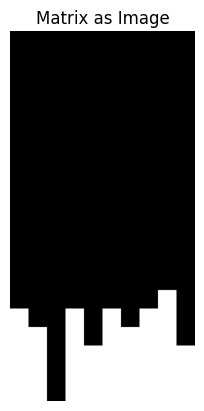

9704 piece remaining.


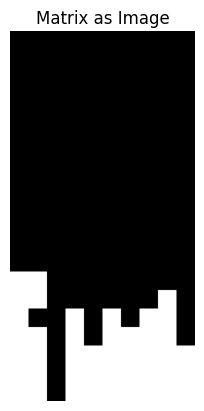

9703 piece remaining.


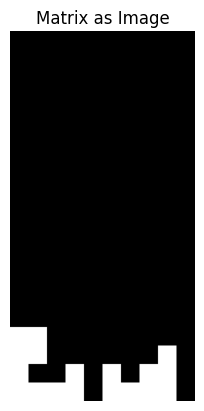

9702 piece remaining.


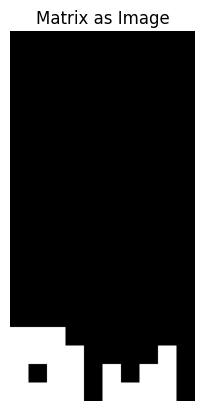

9701 piece remaining.


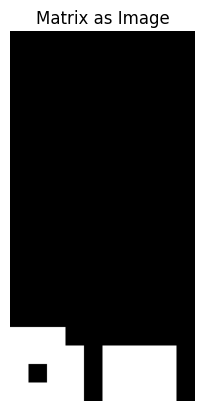

9700 piece remaining.


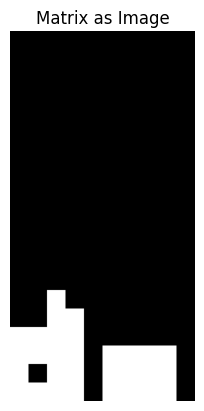

9699 piece remaining.


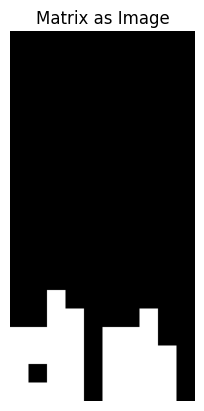

9698 piece remaining.


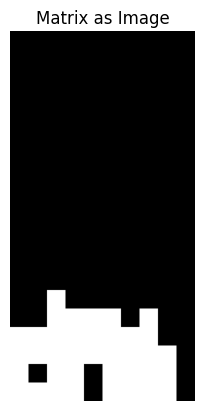

9697 piece remaining.


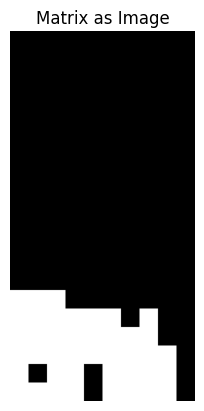

9696 piece remaining.


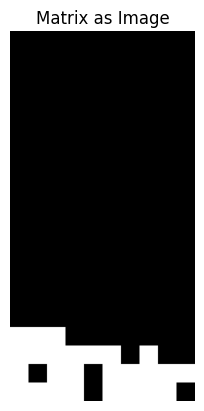

9695 piece remaining.


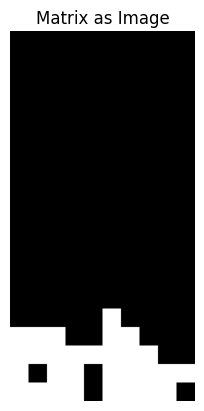

9694 piece remaining.


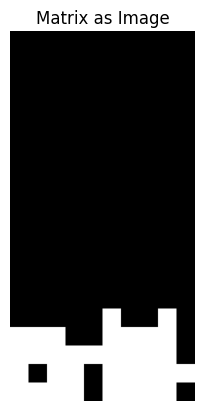

9693 piece remaining.


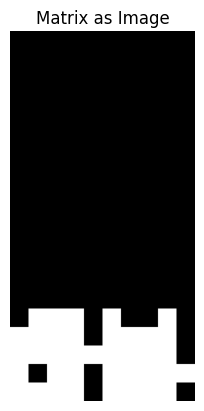

9692 piece remaining.


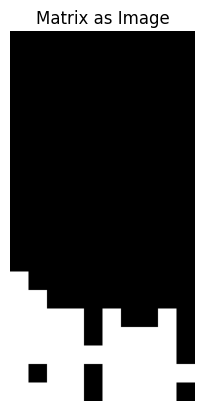

9691 piece remaining.


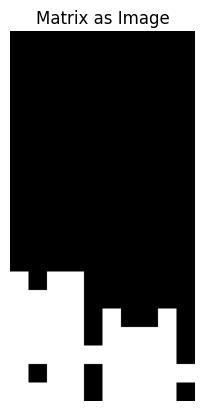

9690 piece remaining.


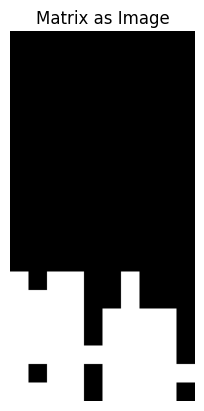

9689 piece remaining.


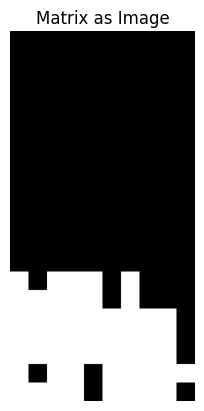

9688 piece remaining.


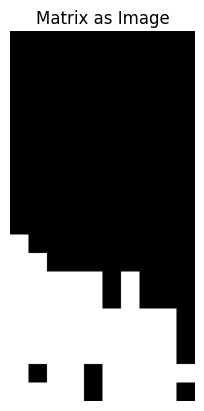

9687 piece remaining.


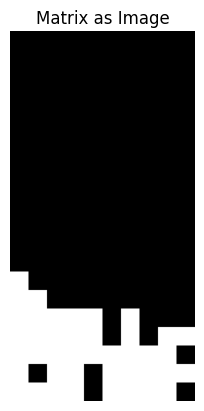

9686 piece remaining.


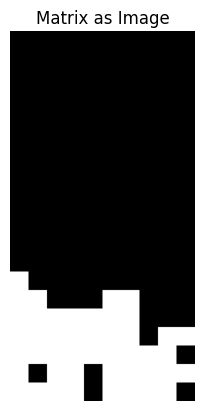

9685 piece remaining.


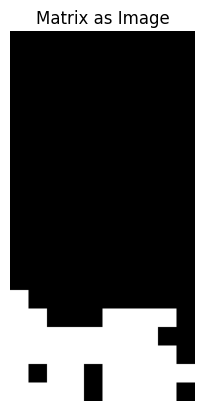

9684 piece remaining.


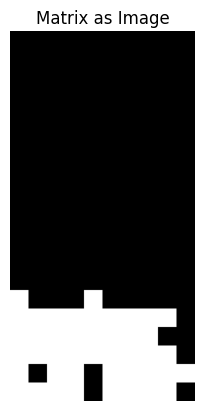

9683 piece remaining.


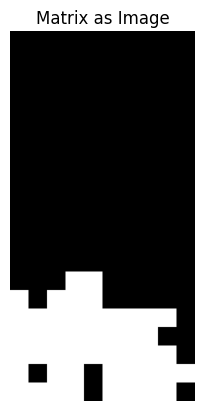

9682 piece remaining.


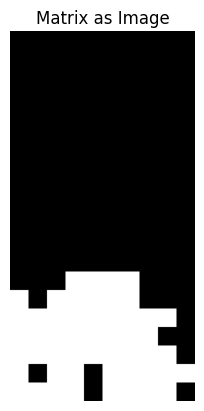

9681 piece remaining.


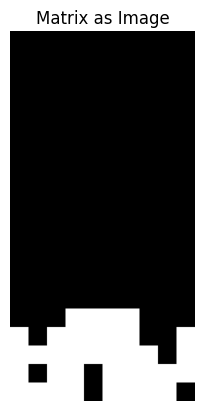

9680 piece remaining.


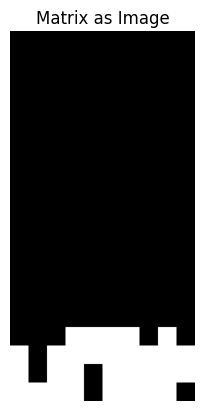

9679 piece remaining.


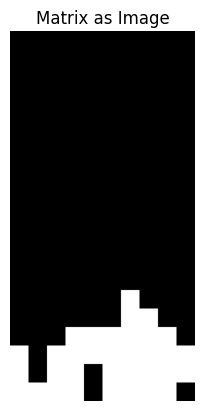

9678 piece remaining.


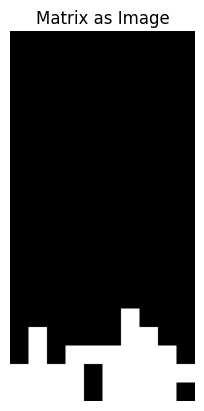

9677 piece remaining.


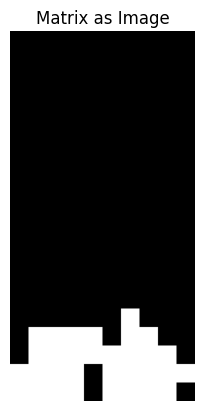

9676 piece remaining.


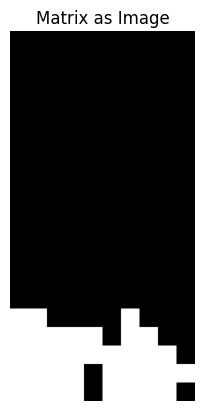

9675 piece remaining.


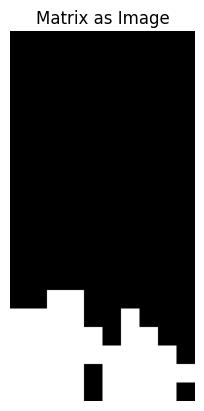

9674 piece remaining.


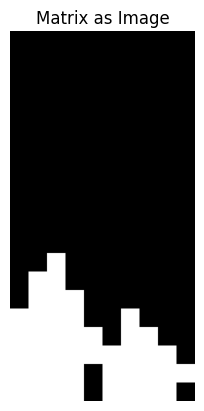

9673 piece remaining.


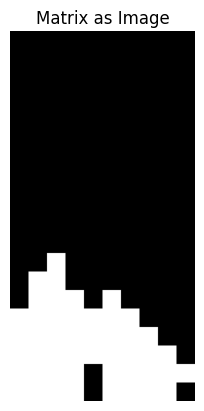

9672 piece remaining.


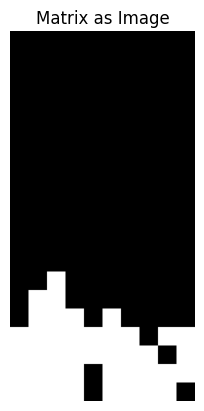

9671 piece remaining.


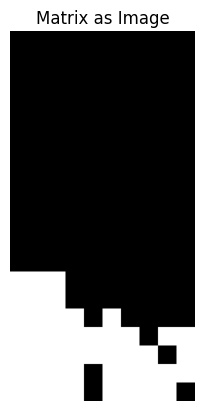

9670 piece remaining.


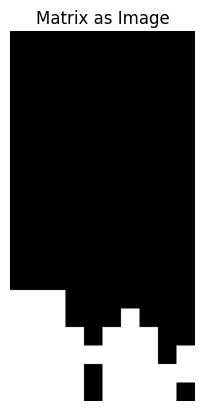

9669 piece remaining.


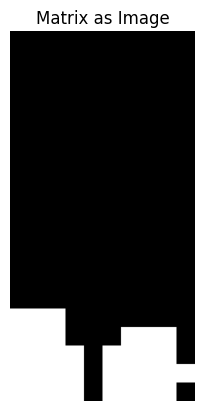

9668 piece remaining.


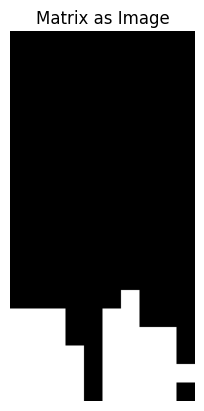

9667 piece remaining.


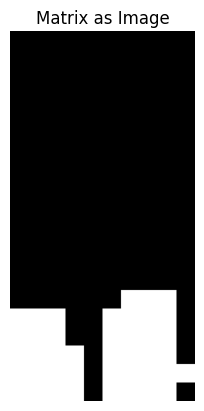

9666 piece remaining.


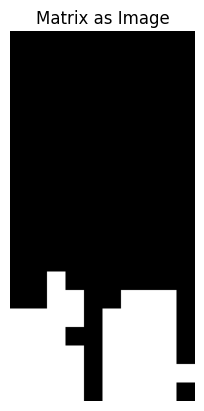

9665 piece remaining.


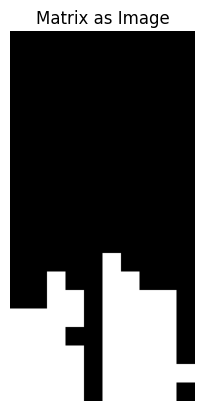

9664 piece remaining.


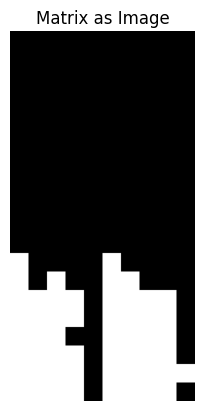

9663 piece remaining.


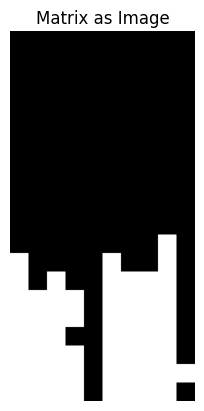

9662 piece remaining.


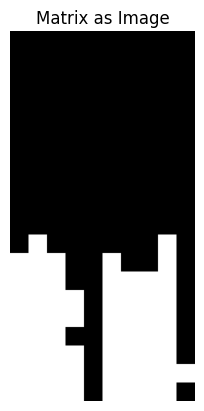

9661 piece remaining.


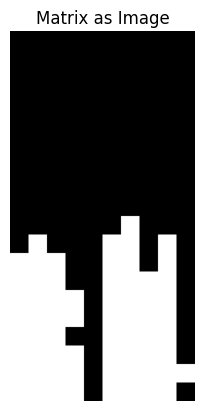

9660 piece remaining.


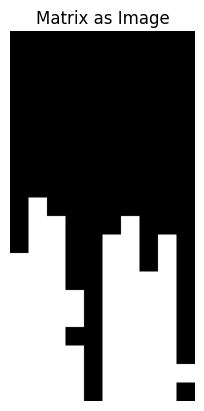

9659 piece remaining.


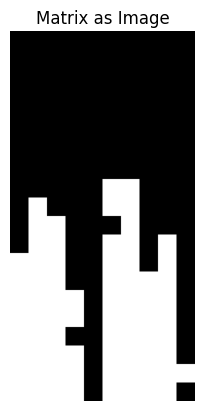

9658 piece remaining.


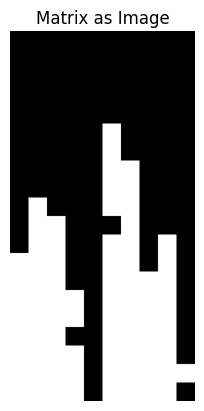

9657 piece remaining.


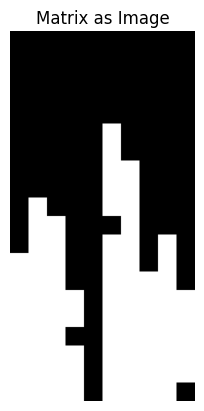

9656 piece remaining.


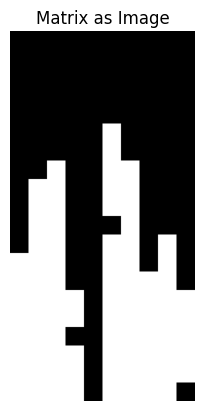

9655 piece remaining.


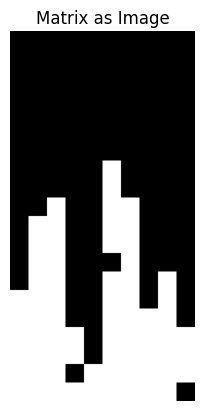

9654 piece remaining.


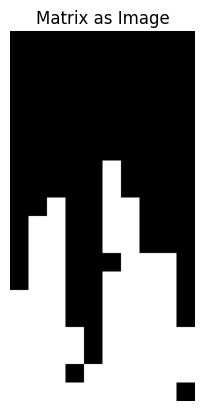

9653 piece remaining.


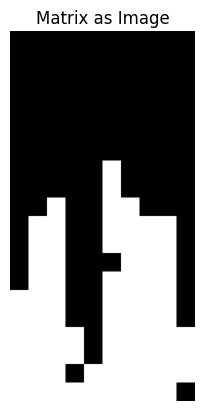

9652 piece remaining.


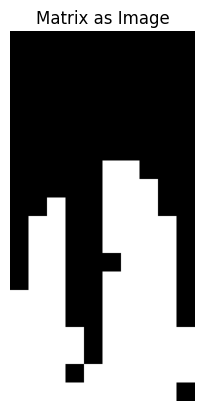

9651 piece remaining.


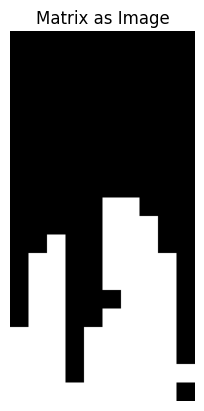

9650 piece remaining.


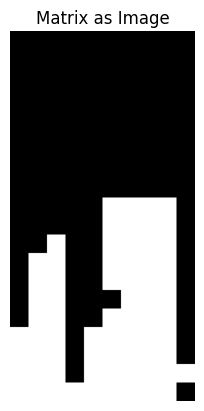

9649 piece remaining.


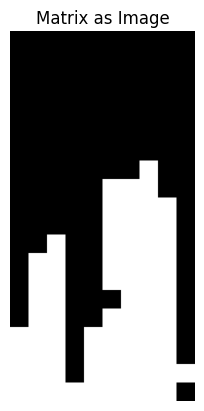

9648 piece remaining.


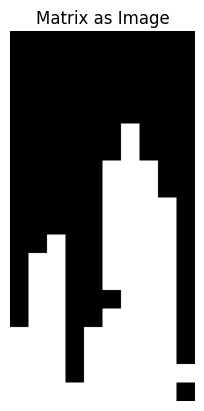

9647 piece remaining.


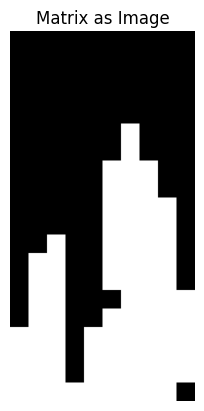

9646 piece remaining.


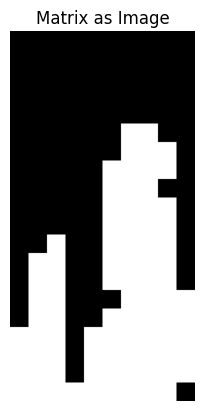

9645 piece remaining.


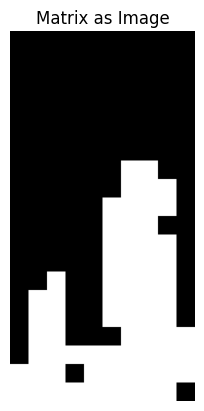

9644 piece remaining.


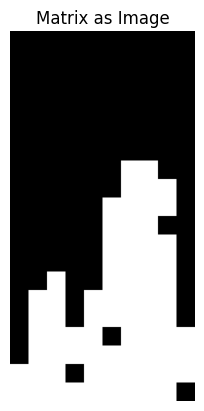

9643 piece remaining.


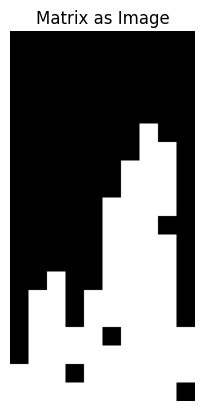

9642 piece remaining.


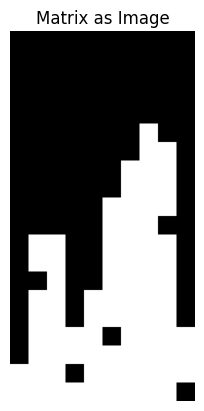

9641 piece remaining.


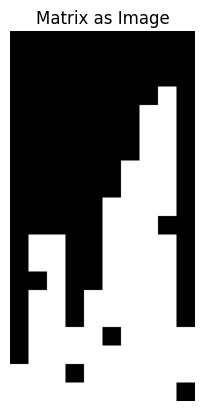

9640 piece remaining.


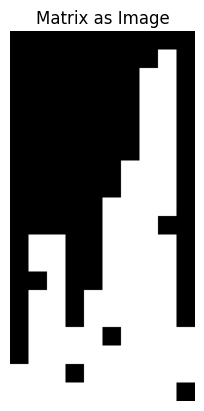

9639 piece remaining.


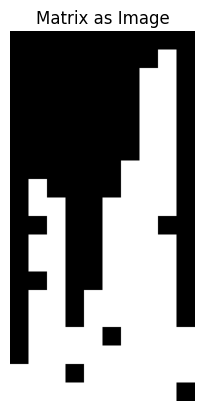

9638 piece remaining.


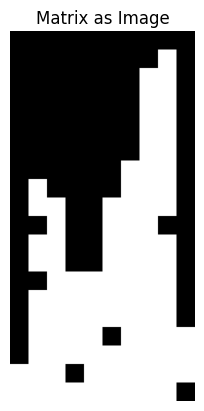

9637 piece remaining.


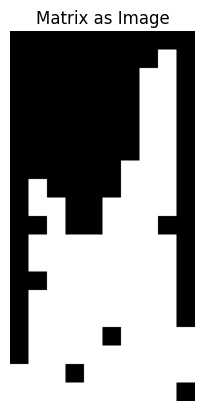

9636 piece remaining.


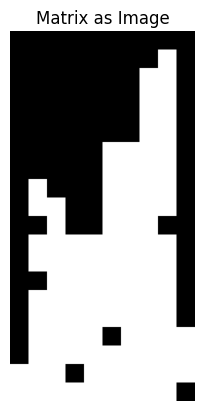

9635 piece remaining.


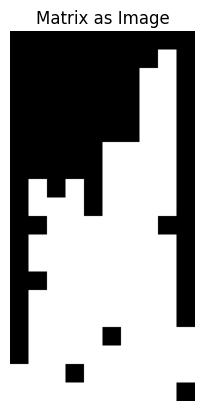

9634 piece remaining.


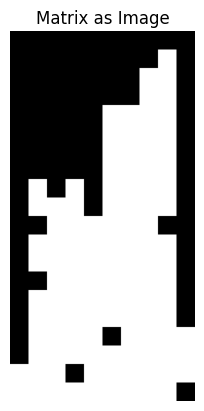

9633 piece remaining.


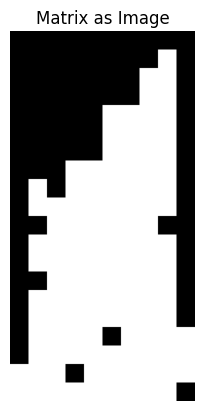

9632 piece remaining.


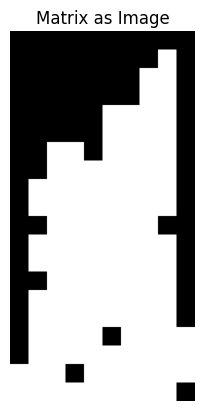

9631 piece remaining.


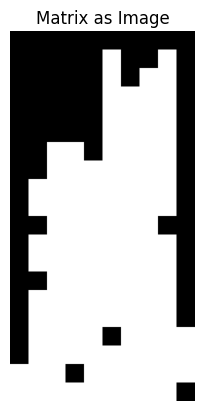

9630 piece remaining.


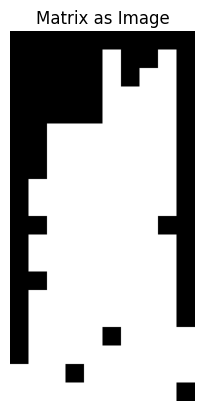

9629 piece remaining.


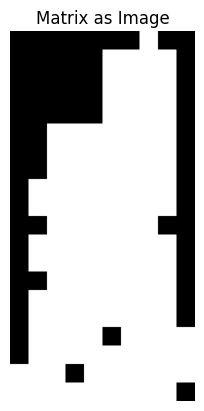

9628 piece remaining.


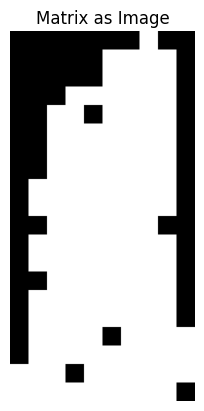

9627 piece remaining.


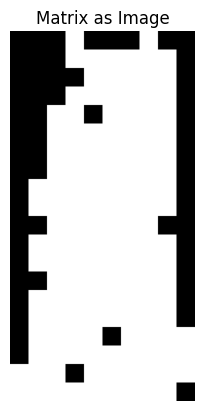

9626 piece remaining.


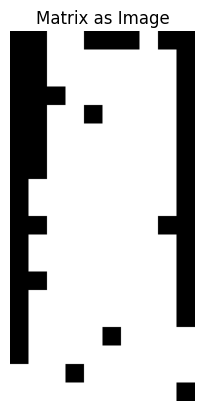

9625 piece remaining.


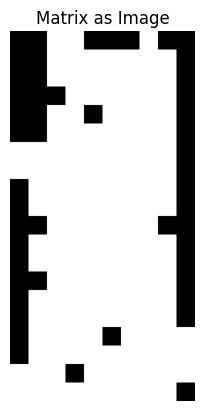

9624 piece remaining.


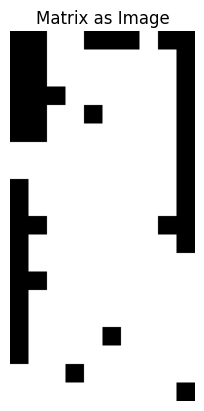

9623 piece remaining.


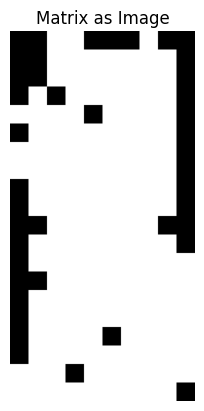

9622 piece remaining.


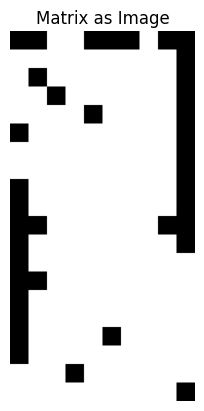

I lost.
9621 pieces left with a total of 229 points 
My grade is 219.135201302079.


In [20]:
# which can easily be generalized for a full game,
# hints of what I plan to do is given, cod is not complete
# similarly prepare the game
H,W = 20, 10
M = np.zeros((H,W)) # empty board
nPreview = 3 # number of pieces in the preview, 0 does not make sense though, if you want to test without preview, simply do not send FollowingPieces argument
PP = [] # list of preview items
for i in range(nPreview+1): # fill in the list randomly with +1 that represents the piece2place
    PP.append( Pieces[np.random.randint(0, len(Pieces))] )

N = 10000 # let's start with shorter games
nPopLines = 0 # number of lines popped
gameScore = 0 # well, game score

while N > 0 : #  positive is a good sign to continue
    N = N -1 # decrement loop counter till it expires to finish the game
    pf, i2p = TetrisNext(M, PP.pop(), PP)
    i,j = i2p
    if (i+j) == -2:
        print('I lost.')
        break

    M[i2p[0]:i2p[0]+pf.shape[0], i2p[1]:i2p[1]+pf.shape[1]] = M[i2p[0]:i2p[0]+pf.shape[0], i2p[1]:i2p[1]+pf.shape[1]] + pf
    M,gameScore = break_lines(M,gameScore)
    # now that PP is one less, append a random piece to it
    PP.append( Pieces[np.random.randint(0, len(Pieces))] )
    # if not check if there are lines to pop, and update running score
    print(f'{N} piece remaining.')
    MatImshow(M)

print(f'{N} pieces left with a total of {gameScore} points ')
Grade = gameScore - math.log(2*N-1)
if gameScore < 80:
    print(f'My best is 932.2745. If you wanna see it, you can run me again :).')
print(f'My grade is {Grade}.')